# Leveraging Machine Learning for Predictive Price Analytics & Algorithmic Trading Strategy Optimization

## This research leverages machine learning to analyse historical market data, forecast price trends, and identify effective trading strategies to create portfolio. By enabling data-driven insights, it empowers investors to optimize strategy parameters, enhance ## decision-making, and improve trading performance.

This dissertation presents a comprehensive study of three innovative algorithmic trading strategies that integrate machine learning, social sentiment analysis, and volatility modeling. Developed through hands-on Python projects, the dissertation emphasizes practical implementation, quantitative finance, and data-driven decision-making.

The first strategy employs unsupervised learning—specifically K-means clustering with momentum-based initialization—to categorize S&P 500 stocks and construct diversified, Sharpe-optimized portfolios. The second explores Twitter sentiment as a signal for constructing sentiment-ranked, equal-weighted portfolios from NASDAQ 100 stocks, showcasing the influence of social media on investor behavior. The final strategy focuses on intraday trading of a single asset using GARCH-based volatility forecasting, enhanced with technical indicators such as RSI and Bollinger Bands to generate predictive trade signals.

Key themes include data preprocessing, rolling factor analysis, portfolio optimization, risk management, and rigorous backtesting. Each strategy is benchmarked against market indices like the S&P 500 and NASDAQ to assess real-world relevance and performance. The dissertation underlines the importance of clean data, dynamic modeling, and practical coding proficiency in Python, offering a valuable blend of financial theory and applied machine learning.

Prerequities packages

pandas, numpy, matplotlib, statsmodels, pandas_datareader, datetime, yfinance, sklearn, 
--PyPortfolioOpt is a Python library designed for portfolio optimization and asset allocation. It provides tools for implementing modern portfolio theory and advanced portfolio optimization techniques. Here are its key features and capabilities:
PyPortfolioOpt

# [A] Unsupervised learning on S&P 500 for portfolio optimization

Sourcing S&P_500 price data
https://en.wikipedia.org/wiki/List_of_S%26P_500_companies

In [5]:
# Rolling Ordinary Least Squares regression model from statsmodels, used for time-varying regression analysis on financial time series data
from statsmodels.regression.rolling import RollingOLS

#Provides functions to fetch financial data from various online sources
import pandas_datareader.data as web

import matplotlib.pyplot as plt

# Statistical modeling package for regression analysis and hypothesis testing
import statsmodels.api as sm

import pandas as pd
import numpy as np
import datetime as dt

# Yahoo Finance API wrapper to download market data
import yfinance as yf

# Pandas_ta is a powerful technical analysis library that extends pandas functionality specifically for financial market analysis
# Contains over 130 technical indicators including:Moving averages (SMA, EMA, WMA, etc.), Momentum indicators (RSI, MACD, Stochastic), Volatility indicators (Bollinger Bands, ATR)
import pandas_ta as ta

import warnings
#Suppresses warning messages that might appear during execution
warnings.filterwarnings('ignore')

# Configures pandas to display all columns in DataFrames
pd.set_option('display.max_columns', None)

In [6]:
import pandas_ta

1. Download/Load SP500 stocks prices data.

In [8]:
# This code retrieves S&P 500 company data and downloads historical stock prices.
wiki_sp500 = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]

# Replaces dots with hyphens in ticker symbols to match Yahoo Finance's format
wiki_sp500['Symbol'] = wiki_sp500['Symbol'].str.replace('.', '-')

# Creates a list of unique ticker symbols from the S&P 500 companies
symbols_list = wiki_sp500['Symbol'].unique().tolist()

end_date = '2025-03-25'

# Calculates the start date as 8 years before the end date
start_date = pd.to_datetime(end_date)-pd.DateOffset(365*8)

# `auto_adjust=False` keeps the unadjusted prices
df_sp500 = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date, auto_adjust=False).stack()

# Names the MultiIndex levels as 'date' and 'ticker'
df_sp500.index.names = ['date', 'ticker']

# Converts all column names to lowercase
df_sp500.columns = df_sp500.columns.str.lower()

df_sp500

[*********************100%***********************]  503 of 503 completed


Price               adj close       close        high         low        open  \
date       ticker                                                               
2017-03-27 A        49.988941   53.240002   53.340000   52.419998   52.599998   
           AAPL     32.723080   35.220001   35.305000   34.654999   34.847500   
           ABBV     46.913124   66.099998   66.279999   65.239998   65.370003   
           ABT      38.723362   44.700001   44.799999   44.389999   44.529999   
           ACGL     29.569775   31.096666   31.136667   30.500000   30.936666   
...                       ...         ...         ...         ...         ...   
2025-03-24 XYL     120.800003  120.800003  121.099998  119.279999  119.970001   
           YUM     155.820007  155.820007  157.720001  155.029999  157.070007   
           ZBH     111.002174  111.239998  112.279999  110.690002  110.930000   
           ZBRA    297.410004  297.410004  301.769989  293.859985  294.329987   
           ZTS     163.169998  163.169998  165.479996  161.699997  162.270004   

Price                  volume  
date       ticker              
2017-03-27 A        1446500.0  
           AAPL    94300400.0  
           ABBV     4962300.0  
           ABT      6914700.0  
           ACGL      811500.0  
...                       ...  
2025-03-24 XYL      2251800.0  
           YUM      1952500.0  
           ZBH      1034000.0  
           ZBRA      512000.0  
           ZTS      1817400.0  

[990561 rows x 6 columns]

2. Calculate features and technical indicators for each stock.

        Garman-Klass Volatility
        RSI
        Bollinger Bands
        ATR
        MACD
        Dollar Volume

In [10]:
# Calculates the Garman-Klass volatility estimator for the S&P 500 stock data and displays the first 5 rows of the resulting DataFrame.
# The Garman-Klass volatility estimator is an advanced method for estimating price volatility that uses high, low, open, and close prices. It's more efficient than traditional close-to-close volatility measures because it incorporates the trading range information.
df_sp500['garman_klass_vol'] = ((np.log(df_sp500['high'])-np.log(df_sp500['low']))**2)/2-(2*np.log(2)-1)*((np.log(df_sp500['adj close'])-np.log(df_sp500['open']))**2)

df_sp500.head(5)

Price              adj close      close       high        low       open  \
date       ticker                                                          
2017-03-27 A       49.988941  53.240002  53.340000  52.419998  52.599998   
           AAPL    32.723080  35.220001  35.305000  34.654999  34.847500   
           ABBV    46.913124  66.099998  66.279999  65.239998  65.370003   
           ABT     38.723362  44.700001  44.799999  44.389999  44.529999   
           ACGL    29.569775  31.096666  31.136667  30.500000  30.936666   

Price                  volume  garman_klass_vol  
date       ticker                                
2017-03-27 A        1446500.0         -0.000850  
           AAPL    94300400.0         -0.001356  
           ABBV     4962300.0         -0.042394  
           ABT      6914700.0         -0.007499  
           ACGL      811500.0         -0.000575

In [11]:
# rsi
# calculates the Relative Strength Index (RSI) for each stock in the S&P 500 dataset and displays the first 5 rows of the resulting DataFrame.
# The Relative Strength Index (RSI) is a momentum oscillator that measures the speed and change of price movements. It oscillates between 0 and 100 and is typically used to identify overbought or oversold conditions in a market.
# RSI values above 70 typically indicate overbought conditions, while values below 30 suggest oversold conditions.
df_sp500['rsi'] = df_sp500.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))

df_sp500.head(5)

Price              adj close      close       high        low       open  \
date       ticker                                                          
2017-03-27 A       49.988941  53.240002  53.340000  52.419998  52.599998   
           AAPL    32.723080  35.220001  35.305000  34.654999  34.847500   
           ABBV    46.913124  66.099998  66.279999  65.239998  65.370003   
           ABT     38.723362  44.700001  44.799999  44.389999  44.529999   
           ACGL    29.569775  31.096666  31.136667  30.500000  30.936666   

Price                  volume  garman_klass_vol  rsi  
date       ticker                                     
2017-03-27 A        1446500.0         -0.000850  NaN  
           AAPL    94300400.0         -0.001356  NaN  
           ABBV     4962300.0         -0.042394  NaN  
           ABT      6914700.0         -0.007499  NaN  
           ACGL      811500.0         -0.000575  NaN

In [12]:
# Bollinger Bands 
# Calculates the lower Bollinger Band for each stock in the S&P 500 dataset and displays the first 5 rows of the resulting DataFrame.(Lower Band)
# Bollinger Bands are a technical analysis tool that consists of a middle band (typically a 20-period simple moving average) and two outer bands that are standard deviations away from the middle band. They help identify volatility and potential overbought/oversold conditions.
# The lower Bollinger Band can be used to identify potential support levels or oversold conditions when prices approach or cross below this band.
df_sp500['bb_low'] = df_sp500.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,0])

df_sp500.head(5)

Price              adj close      close       high        low       open  \
date       ticker                                                          
2017-03-27 A       49.988941  53.240002  53.340000  52.419998  52.599998   
           AAPL    32.723080  35.220001  35.305000  34.654999  34.847500   
           ABBV    46.913124  66.099998  66.279999  65.239998  65.370003   
           ABT     38.723362  44.700001  44.799999  44.389999  44.529999   
           ACGL    29.569775  31.096666  31.136667  30.500000  30.936666   

Price                  volume  garman_klass_vol  rsi  bb_low  
date       ticker                                             
2017-03-27 A        1446500.0         -0.000850  NaN     NaN  
           AAPL    94300400.0         -0.001356  NaN     NaN  
           ABBV     4962300.0         -0.042394  NaN     NaN  
           ABT      6914700.0         -0.007499  NaN     NaN  
           ACGL      811500.0         -0.000575  NaN     NaN

In [13]:
# Bollinger Bands (Middle Band)
# calculates the middle Bollinger Band for each stock in the S&P 500 dataset and displays the first 5 rows of the resulting DataFrame.
# The middle Bollinger Band is simply a simple moving average (SMA) of the price over a specified period, typically 20 days. It serves as the baseline for the upper and lower bands and represents the average price trend.
# Using the middle band in conjunction with the lower band (calculated previously):
# When price is above the middle band, it suggests a bullish trend
# When price is below the middle band, it suggests a bearish trend
# The middle band can act as support in uptrends and resistance in downtrends
# The distance between price and the middle band can indicate the strength of a trend

df_sp500['bb_mid'] = df_sp500.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,1])

df_sp500.head(5)

Price              adj close      close       high        low       open  \
date       ticker                                                          
2017-03-27 A       49.988941  53.240002  53.340000  52.419998  52.599998   
           AAPL    32.723080  35.220001  35.305000  34.654999  34.847500   
           ABBV    46.913124  66.099998  66.279999  65.239998  65.370003   
           ABT     38.723362  44.700001  44.799999  44.389999  44.529999   
           ACGL    29.569775  31.096666  31.136667  30.500000  30.936666   

Price                  volume  garman_klass_vol  rsi  bb_low  bb_mid  
date       ticker                                                     
2017-03-27 A        1446500.0         -0.000850  NaN     NaN     NaN  
           AAPL    94300400.0         -0.001356  NaN     NaN     NaN  
           ABBV     4962300.0         -0.042394  NaN     NaN     NaN  
           ABT      6914700.0         -0.007499  NaN     NaN     NaN  
           ACGL      811500.0         -0.000575  NaN     NaN     NaN

In [14]:
# Bollinger Bands (Upper Band)
# Calculates the upper Bollinger Band for each stock in the S&P 500 dataset and displays the first 5 rows of the resulting DataFrame.
# The upper Bollinger Band is typically calculated as the middle band (20-day SMA) plus two standard deviations of price. It represents a statistical upper range for price movement and is often used to identify overbought conditions or potential resistance levels.
df_sp500['bb_high'] = df_sp500.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,2])

df_sp500.head(5)

Price              adj close      close       high        low       open  \
date       ticker                                                          
2017-03-27 A       49.988941  53.240002  53.340000  52.419998  52.599998   
           AAPL    32.723080  35.220001  35.305000  34.654999  34.847500   
           ABBV    46.913124  66.099998  66.279999  65.239998  65.370003   
           ABT     38.723362  44.700001  44.799999  44.389999  44.529999   
           ACGL    29.569775  31.096666  31.136667  30.500000  30.936666   

Price                  volume  garman_klass_vol  rsi  bb_low  bb_mid  bb_high  
date       ticker                                                              
2017-03-27 A        1446500.0         -0.000850  NaN     NaN     NaN      NaN  
           AAPL    94300400.0         -0.001356  NaN     NaN     NaN      NaN  
           ABBV     4962300.0         -0.042394  NaN     NaN     NaN      NaN  
           ABT      6914700.0         -0.007499  NaN     NaN     NaN      NaN  
           ACGL      811500.0         -0.000575  NaN     NaN     NaN      NaN

Now that all three Bollinger Bands have been calculated (lower, middle, and upper), you have a complete Bollinger Bands indicator system that can be used for:

1. **Volatility Assessment**: The width between the bands indicates market volatility
   - Wider bands = higher volatility
   - Narrower bands = lower volatility

2. **Trend Identification**:
   - Price consistently near the upper band suggests a strong uptrend
   - Price consistently near the lower band suggests a strong downtrend

3. **Reversal Signals**:
   - When price touches or exceeds the upper band and then moves back inside, it may signal a potential reversal
   - When price touches or falls below the lower band and then moves back inside, it may signal a potential reversal

4. **"Bollinger Squeeze"**: When the bands contract significantly, it often precedes a period of increased volatility and potential breakout

The log transformation of prices helps normalize the data and can make the Bollinger Bands more consistent across different price levels.

In [15]:
# Average True Range (ATR) Function
# defines a function called `compute_atr` that calculates the normalized Average True Range (ATR) for stock data.
# The Average True Range (ATR) is a technical indicator that measures market volatility by decomposing the entire range of an asset price for a specific period. It was originally developed by J. Welles Wilder Jr. for commodities but is now commonly used for stocks and other financial instruments.
def compute_atr(stock_data):
    atr = pandas_ta.atr(high=stock_data['high'],
                        low=stock_data['low'],
                        close=stock_data['close'],
                        length=14)
    return atr.sub(atr.mean()).div(atr.std())

In [16]:
# applies the previously defined `compute_atr` function to calculate the normalized Average True Range (ATR) for each stock in the S&P 500 dataset and displays the first 5 rows of the resulting DataFrame.
df_sp500['atr'] = df_sp500.groupby(level=1, group_keys=False).apply(compute_atr)

df_sp500.head(5)

Price              adj close      close       high        low       open  \
date       ticker                                                          
2017-03-27 A       49.988941  53.240002  53.340000  52.419998  52.599998   
           AAPL    32.723080  35.220001  35.305000  34.654999  34.847500   
           ABBV    46.913124  66.099998  66.279999  65.239998  65.370003   
           ABT     38.723362  44.700001  44.799999  44.389999  44.529999   
           ACGL    29.569775  31.096666  31.136667  30.500000  30.936666   

Price                  volume  garman_klass_vol  rsi  bb_low  bb_mid  bb_high  \
date       ticker                                                               
2017-03-27 A        1446500.0         -0.000850  NaN     NaN     NaN      NaN   
           AAPL    94300400.0         -0.001356  NaN     NaN     NaN      NaN   
           ABBV     4962300.0         -0.042394  NaN     NaN     NaN      NaN   
           ABT      6914700.0         -0.007499  NaN     NaN     NaN      NaN   
           ACGL      811500.0         -0.000575  NaN     NaN     NaN      NaN   

Price              atr  
date       ticker       
2017-03-27 A       NaN  
           AAPL    NaN  
           ABBV    NaN  
           ABT     NaN  
           ACGL    NaN

### What This Achieves:

The resulting 'atr' column contains normalized ATR values for each stock, where:
- Values near 0 indicate volatility close to the stock's historical average
- Positive values indicate above-average volatility
- Negative values indicate below-average volatility
- Values of +1 or -1 represent volatility that's one standard deviation above or below the mean

Since the ATR is normalized for each stock individually, the values can be directly compared across different stocks regardless of their price levels. This makes it possible to:

1. **Identify Volatility Outliers**: Stocks with unusually high or low volatility relative to their own history
2. **Create Volatility-Based Filters**: For example, focusing on stocks with normalized ATR > 2 (unusually volatile)
3. **Develop Trading Strategies**: Such as volatility breakout strategies or mean-reversion approaches
4. **Risk Management**: Adjust position sizes based on current volatility relative to historical norms

The normalization process makes this ATR implementation particularly useful for portfolio analysis and cross-sectional comparisons across the entire S&P 500 universe.

In [17]:
# Normalized MACD Function
# defines a function called `compute_macd` that calculates and normalizes the Moving Average Convergence Divergence (MACD) indicator for a given price series
# The Moving Average Convergence Divergence (MACD) is a trend-following momentum indicator that shows the relationship between two moving averages of a security's price. It's calculated by subtracting the 26-period Exponential Moving Average (EMA) from the 12-period EMA.
def compute_macd(close):
    macd = pandas_ta.macd(close=close, length=20).iloc[:,0]
    return macd.sub(macd.mean()).div(macd.std())

In [18]:
# applies the previously defined `compute_macd` function to calculate the normalized Moving Average Convergence Divergence (MACD) for each stock in the S&P 500 dataset.
df_sp500['macd'] = df_sp500.groupby(level=1, group_keys=False)['adj close'].apply(compute_macd)

### What This Achieves:

The resulting 'macd' column contains normalized MACD values for each stock, where:
- Values near 0 indicate momentum close to the stock's historical average
- Positive values indicate above-average momentum (bullish)
- Negative values indicate below-average momentum (bearish)
- Values of +1 or -1 represent momentum that's one standard deviation above or below the mean

### Benefits of This Approach:

1. **Standardized Comparison**: By normalizing the MACD for each stock, you can directly compare momentum across different securities regardless of their price levels or volatility characteristics.

2. **Statistical Context**: The normalization provides statistical context - you can easily identify stocks with unusually strong or weak momentum (e.g., > 2 standard deviations from mean).

3. **Portfolio Applications**:
   - Ranking stocks by normalized MACD for momentum-based portfolio construction
   - Identifying potential mean-reversion candidates (extremely high or low values)
   - Creating momentum-based filters for stock selection

4. **Sector Analysis**: Comparing momentum across different sectors by aggregating the normalized MACD values

This implementation creates a powerful tool for analyzing relative momentum across the entire S&P 500 universe, which can be particularly useful for quantitative trading strategies and portfolio management.

In [19]:
df_sp500

Price               adj close       close        high         low        open  \
date       ticker                                                               
2017-03-27 A        49.988941   53.240002   53.340000   52.419998   52.599998   
           AAPL     32.723080   35.220001   35.305000   34.654999   34.847500   
           ABBV     46.913124   66.099998   66.279999   65.239998   65.370003   
           ABT      38.723362   44.700001   44.799999   44.389999   44.529999   
           ACGL     29.569775   31.096666   31.136667   30.500000   30.936666   
...                       ...         ...         ...         ...         ...   
2025-03-24 XYL     120.800003  120.800003  121.099998  119.279999  119.970001   
           YUM     155.820007  155.820007  157.720001  155.029999  157.070007   
           ZBH     111.002174  111.239998  112.279999  110.690002  110.930000   
           ZBRA    297.410004  297.410004  301.769989  293.859985  294.329987   
           ZTS     163.169998  163.169998  165.479996  161.699997  162.270004   

Price                  volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2017-03-27 A        1446500.0         -0.000850        NaN       NaN   
           AAPL    94300400.0         -0.001356        NaN       NaN   
           ABBV     4962300.0         -0.042394        NaN       NaN   
           ABT      6914700.0         -0.007499        NaN       NaN   
           ACGL      811500.0         -0.000575        NaN       NaN   
...                       ...               ...        ...       ...   
2025-03-24 XYL      2251800.0          0.000096  43.098372  4.773920   
           YUM      1952500.0          0.000123  59.976874  5.029340   
           ZBH      1034000.0          0.000102  56.957234  4.630185   
           ZBRA      512000.0          0.000311  40.455044  5.594693   
           ZTS      1817400.0          0.000255  46.334960  5.076773   

Price                bb_mid   bb_high       atr      macd  
date       ticker                                          
2017-03-27 A            NaN       NaN       NaN       NaN  
           AAPL         NaN       NaN       NaN       NaN  
           ABBV         NaN       NaN       NaN       NaN  
           ABT          NaN       NaN       NaN       NaN  
           ACGL         NaN       NaN       NaN       NaN  
...                     ...       ...       ...       ...  
2025-03-24 XYL     4.837946  4.901973  0.752590 -1.235186  
           YUM     5.060034  5.090729  1.228922  1.833644  
           ZBH     4.688327  4.746469 -0.160985  0.776722  
           ZBRA    5.684525  5.774358  0.272976 -1.869798  
           ZTS     5.115614  5.154455  0.519857 -0.594155  

[990561 rows x 13 columns]

In [20]:
# calculates the dollar volume for each stock in the S&P 500 dataset and stores it in a new column.
# Dollar volume is a measure of trading activity that combines both price and volume information. It represents the total monetary value of shares traded during a specific period.
df_sp500['dollar_volume'] = (df_sp500['adj close']*df_sp500['volume'])/1e6

### Why Dollar Volume Matters:

1. **Liquidity Indicator**: Higher dollar volume generally indicates higher liquidity, meaning it's easier to buy or sell large positions without significantly impacting the price.

2. **Market Interest**: It shows the level of investor interest and activity in a stock, which can be more informative than looking at share volume alone.

3. **Size-Adjusted Comparison**: It allows for more meaningful comparisons between stocks with different price levels. For example:
   - Stock A: $10 price × 1,000,000 shares = $10 million dollar volume
   - Stock B: $100 price × 100,000 shares = $10 million dollar volume
   - Both have the same dollar volume despite very different share volumes

4. **Trading Strategy Applications**:
   - Screening for highly liquid stocks
   - Identifying unusual trading activity
   - Setting position sizes based on typical liquidity
   - Analyzing changes in market interest over time

5. **Technical Analysis**: Some technical indicators and patterns are more reliable in stocks with higher dollar volume.

By scaling to millions (`/1e6`), the values become more manageable and easier to interpret in reports and visualizations. For example, a value of 25.5 would represent $25.5 million in trading value for that day.

In [21]:
df_sp500

Price               adj close       close        high         low        open  \
date       ticker                                                               
2017-03-27 A        49.988941   53.240002   53.340000   52.419998   52.599998   
           AAPL     32.723080   35.220001   35.305000   34.654999   34.847500   
           ABBV     46.913124   66.099998   66.279999   65.239998   65.370003   
           ABT      38.723362   44.700001   44.799999   44.389999   44.529999   
           ACGL     29.569775   31.096666   31.136667   30.500000   30.936666   
...                       ...         ...         ...         ...         ...   
2025-03-24 XYL     120.800003  120.800003  121.099998  119.279999  119.970001   
           YUM     155.820007  155.820007  157.720001  155.029999  157.070007   
           ZBH     111.002174  111.239998  112.279999  110.690002  110.930000   
           ZBRA    297.410004  297.410004  301.769989  293.859985  294.329987   
           ZTS     163.169998  163.169998  165.479996  161.699997  162.270004   

Price                  volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2017-03-27 A        1446500.0         -0.000850        NaN       NaN   
           AAPL    94300400.0         -0.001356        NaN       NaN   
           ABBV     4962300.0         -0.042394        NaN       NaN   
           ABT      6914700.0         -0.007499        NaN       NaN   
           ACGL      811500.0         -0.000575        NaN       NaN   
...                       ...               ...        ...       ...   
2025-03-24 XYL      2251800.0          0.000096  43.098372  4.773920   
           YUM      1952500.0          0.000123  59.976874  5.029340   
           ZBH      1034000.0          0.000102  56.957234  4.630185   
           ZBRA      512000.0          0.000311  40.455044  5.594693   
           ZTS      1817400.0          0.000255  46.334960  5.076773   

Price                bb_mid   bb_high       atr      macd  dollar_volume  
date       ticker                                                         
2017-03-27 A            NaN       NaN       NaN       NaN      72.309003  
           AAPL         NaN       NaN       NaN       NaN    3085.799503  
           ABBV         NaN       NaN       NaN       NaN     232.796996  
           ABT          NaN       NaN       NaN       NaN     267.760431  
           ACGL         NaN       NaN       NaN       NaN      23.995872  
...                     ...       ...       ...       ...            ...  
2025-03-24 XYL     4.837946  4.901973  0.752590 -1.235186     272.017447  
           YUM     5.060034  5.090729  1.228922  1.833644     304.238564  
           ZBH     4.688327  4.746469 -0.160985  0.776722     114.776248  
           ZBRA    5.684525  5.774358  0.272976 -1.869798     152.273922  
           ZTS     5.115614  5.154455  0.519857 -0.594155     296.545155  

[990561 rows x 14 columns]

3. Aggregate to monthly level and filter top 150 most liquid stocks for each month.

To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.

This code performs several operations to transform the S&P 500 data from daily to monthly frequency and selects specific columns for analysis.

This creates a list of column names excluding basic price and volume data:
1. `df_sp500.columns.unique(0)` gets all unique column names at level 0
2. The list comprehension filters out 'dollar_volume', 'volume', 'open', 'high', 'low', and 'close'
3. The remaining columns are likely the technical indicators calculated earlier (e.g., 'adj close', 'garman_klass_vol', 'rsi', 'bb_low', 'bb_mid', 'bb_high', 'atr', 'macd')
4. `print(last_cols)` displays this list of columns

1. **Unstacks and Resamples Dollar Volume**:
   - `df_sp500.unstack('ticker')['dollar_volume']` - Unstacks the ticker level, creating columns for each stock
   - `.resample('M').mean()` - Resamples to monthly frequency, taking the mean of dollar volume
   - `.stack('ticker')` - Restacks to return to the MultiIndex format
   - `.to_frame('dollar_volume')` - Converts to a DataFrame with column name 'dollar_volume'

2. **Unstacks and Resamples Technical Indicators**:
   - `df_sp500.unstack()[last_cols]` - Unstacks the ticker level for the technical indicators
   - `.resample('M').last()` - Resamples to monthly frequency, taking the last value of each month
   - `.stack('ticker')` - Restacks to return to the MultiIndex format

3. **Combines the Results**:
   - `pd.concat([...], axis=1)` - Concatenates the two DataFrames horizontally (along columns)
   - `.dropna()` - Removes any rows with missing values

### Key Points About This Transformation:

1. **Different Aggregation Methods**:
   - Dollar volume uses `mean()` - This captures the average trading activity for the month
   - Technical indicators use `last()` - This captures the end-of-month values

2. **Monthly Frequency**:
   - The `.resample('M')` converts daily data to monthly data
   - This reduces the data size and focuses on longer-term trends

3. **MultiIndex Structure**:
   - The final `data` DataFrame maintains a MultiIndex with date and ticker levels
   - This allows for easy grouping and analysis by both time and stock

4. **Data Cleaning**:
   - `.dropna()` ensures the dataset is clean by removing any rows with missing values

This transformed dataset is now ready for monthly analysis, backtesting of trading strategies, or building predictive models using the technical indicators as features.

In [24]:
last_cols = [c for c in df_sp500.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open',
                                                          'high', 'low', 'close']]

print(last_cols)

data = (pd.concat([df_sp500.unstack('ticker')['dollar_volume'].resample('M').mean().stack('ticker').to_frame('dollar_volume'),
                   df_sp500.unstack()[last_cols].resample('M').last().stack('ticker')],
                  axis=1)).dropna()

data

['adj close', 'garman_klass_vol', 'rsi', 'bb_low', 'bb_mid', 'bb_high', 'atr', 'macd']


dollar_volume   adj close  garman_klass_vol        rsi  \
date       ticker                                                           
2017-05-31 A          125.325438   56.795998         -0.000550  77.368437   
           AAPL      4202.702867   35.628983         -0.002240  60.420529   
           ABBV       267.822617   47.322487         -0.043615  52.892820   
           ABT        232.370875   39.796947         -0.006182  65.436503   
           ACGL        28.368989   30.824963          0.000096  60.155945   
...                          ...         ...               ...        ...   
2025-03-31 XYL        200.847576  120.800003          0.000096  43.098372   
           YUM        332.759411  155.820007          0.000123  59.976874   
           ZBH        215.879845  111.002174          0.000102  56.957234   
           ZBRA       187.156902  297.410004          0.000311  40.455044   
           ZTS        444.342230  163.169998          0.000255  46.334960   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2017-05-31 A       3.953568  4.005900  4.058233 -1.394455  0.548147  
           AAPL    3.564542  3.599417  3.634293 -1.435691 -0.083248  
           ABBV    3.863636  3.879356  3.895076 -1.872880 -0.201313  
           ABT     3.644490  3.674411  3.704332 -1.656801 -0.103038  
           ACGL    3.425951  3.443274  3.460596 -1.227723 -0.195351  
...                     ...       ...       ...       ...       ...  
2025-03-31 XYL     4.773920  4.837946  4.901973  0.752590 -1.235186  
           YUM     5.029340  5.060034  5.090729  1.228922  1.833644  
           ZBH     4.630185  4.688327  4.746469 -0.160985  0.776722  
           ZBRA    5.594693  5.684525  5.774358  0.272976 -1.869798  
           ZTS     5.076773  5.115614  5.154455  0.519857 -0.594155  

[46819 rows x 9 columns]

Calculate 5-year rolling average of dollar volume for each stocks and then use this dollar volume to filter out top 150 most liquid stocks for each month

In [26]:
data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending=False))  # calculte dollar_vol_rank cross sectionally for each month

data = data[data['dollar_vol_rank']<150].drop(['dollar_volume', 'dollar_vol_rank'], axis=1)

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2018-04-30 AAPL     38.993225         -0.000036  44.093198  3.659055   
           ABBV     71.553268         -0.040410  47.693768  4.193913   
           ABT      51.687733         -0.007719  45.310067  3.954631   
           ACN     137.482697         -0.004417  47.986179  4.895865   
           ADBE    221.600006          0.000193  52.184523  5.376595   
...                       ...               ...        ...       ...   
2025-03-31 VZ       43.560001          0.000096  54.486121  3.760999   
           WDAY    249.910004          0.000081  46.991004  5.471258   
           WFC      74.279999          0.000101  51.250123  4.210539   
           WMT      87.489998          0.000059  41.668749  4.404290   
           XOM     115.800003          0.000065  60.565056  4.662864   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2018-04-30 AAPL    3.715842  3.772629 -1.115768 -0.513015  
           ABBV    4.244860  4.295808  0.624326 -0.812190  
           ABT     3.976980  3.999329 -0.834162 -0.428317  
           ACN     4.928325  4.960784 -0.795680 -0.265535  
           ADBE    5.413492  5.450389 -0.872983  0.005181  
...                     ...       ...       ...       ...  
2025-03-31 VZ      3.802040  3.843081  0.702822  1.178491  
           WDAY    5.532535  5.593813  0.988173 -0.735556  
           WFC     4.297638  4.384737  2.978236 -1.211616  
           WMT     4.514098  4.623905  4.144226 -4.661505  
           XOM     4.717553  4.772242  0.990915  1.189121  

[12516 rows x 8 columns]

4. Calculate Monthly Returns for different time horizons as features.

   To capture time series dynamics that reflect for example , momentum patterns for each stocks , we compute historical returns using the method .pct_change(lag), that is, returns over various mpnthly periods as identified by lags

In [28]:
def calculate_returns(df):

    outlier_cutoff = 0.005

    lags = [1, 2, 3, 6, 9, 12] # each in months

    for lag in lags:

        df[f'return_{lag}m'] = (df['adj close']
                              .pct_change(lag)
                              .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                     upper=x.quantile(1-outlier_cutoff)))
                              .add(1)
                              .pow(1/lag)
                              .sub(1))
    return df
    
    
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2019-04-30 AAPL     48.069225         -0.000923  60.713651  3.857410   
           ABBV     61.615757         -0.027754  48.304484  4.110328   
           ABT      71.977180         -0.002464  58.185406  4.217224   
           ACN     169.004059         -0.001948  75.230517  5.088947   
           ADBE    289.250000          0.000077  71.264339  5.573869   
...                       ...               ...        ...       ...   
2025-03-31 VZ       43.560001          0.000096  54.486121  3.760999   
           WDAY    249.910004          0.000081  46.991004  5.471258   
           WFC      74.279999          0.000101  51.250123  4.210539   
           WMT      87.489998          0.000059  41.668749  4.404290   
           XOM     115.800003          0.000065  60.565056  4.662864   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2019-04-30 AAPL    3.894572  3.931734 -1.222967  0.160563   0.056436   
           ABBV    4.148598  4.186868 -0.964263 -0.341273  -0.001829   
           ABT     4.263620  4.310016 -0.519945 -0.190010  -0.000680   
           ACN     5.112715  5.136482 -1.280066  0.549154   0.046375   
           ADBE    5.615850  5.657831 -1.122022  0.437135   0.085407   
...                     ...       ...       ...       ...        ...   
2025-03-31 VZ      3.802040  3.843081  0.702822  1.178491   0.010673   
           WDAY    5.532535  5.593813  0.988173 -0.735556  -0.050999   
           WFC     4.297638  4.384737  2.978236 -1.211616  -0.051583   
           WMT     4.514098  4.623905  4.144226 -4.661505  -0.110331   
           XOM     4.717553  4.772242  0.990915  1.189121   0.040151   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2019-04-30 AAPL     0.076539   0.065846  -0.013082   0.007179    0.017591  
           ABBV     0.007560   0.000633   0.007520  -0.012577   -0.012383  
           ABT      0.014489   0.030596   0.025654   0.023228    0.027978  
           ACN      0.068317   0.062510   0.026297   0.017264    0.017351  
           ADBE     0.049717   0.052880   0.027528   0.018767    0.022450  
...                      ...        ...        ...        ...         ...  
2025-03-31 VZ       0.051601   0.034955   0.000422   0.011625    0.008601  
           WDAY    -0.023457  -0.010602   0.003716   0.012457   -0.007261  
           WFC     -0.026710   0.020490   0.048550   0.027253    0.022934  
           WMT     -0.054618  -0.009760   0.014288   0.029778    0.032656  
           XOM      0.045782   0.027925   0.000817   0.003450    0.002453  

[10345 rows x 14 columns]

5. Download Fama-French Factors and Calculate Rolling Factor Betas.

We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.

Refer - https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

In [31]:
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
                               'famafrench',
                               start='2010')[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()

factor_data = factor_data.resample('M').last().div(100)

factor_data.index.name = 'date'

factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2019-04-30 AAPL    0.0397 -0.0115  0.0216  0.0159 -0.0222   0.056436
           ABBV    0.0397 -0.0115  0.0216  0.0159 -0.0222  -0.001829
           ABT     0.0397 -0.0115  0.0216  0.0159 -0.0222  -0.000680
           ACN     0.0397 -0.0115  0.0216  0.0159 -0.0222   0.046375
           ADBE    0.0397 -0.0115  0.0216  0.0159 -0.0222   0.085407
...                   ...     ...     ...     ...     ...        ...
2024-12-31 VZ     -0.0317 -0.0387 -0.0295  0.0182 -0.0110  -0.096761
           WDAY   -0.0317 -0.0387 -0.0295  0.0182 -0.0110   0.032161
           WFC    -0.0317 -0.0387 -0.0295  0.0182 -0.0110  -0.077852
           WMT    -0.0317 -0.0387 -0.0295  0.0182 -0.0110  -0.021079
           XOM    -0.0317 -0.0387 -0.0295  0.0182 -0.0110  -0.088081

[9921 rows x 6 columns]

In [32]:
factor_data.xs('AAPL', level = 1)
factor_data.head()

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2019-04-30 AAPL    0.0397 -0.0115  0.0216  0.0159 -0.0222   0.056436
           ABBV    0.0397 -0.0115  0.0216  0.0159 -0.0222  -0.001829
           ABT     0.0397 -0.0115  0.0216  0.0159 -0.0222  -0.000680
           ACN     0.0397 -0.0115  0.0216  0.0159 -0.0222   0.046375
           ADBE    0.0397 -0.0115  0.0216  0.0159 -0.0222   0.085407

Filter out stocks with less than 10 months of data. The reason may not  have enough data for many stocks else it may break our system

In [34]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]

factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2019-04-30 AAPL    0.0397 -0.0115  0.0216  0.0159 -0.0222   0.056436
           ABBV    0.0397 -0.0115  0.0216  0.0159 -0.0222  -0.001829
           ABT     0.0397 -0.0115  0.0216  0.0159 -0.0222  -0.000680
           ACN     0.0397 -0.0115  0.0216  0.0159 -0.0222   0.046375
           ADBE    0.0397 -0.0115  0.0216  0.0159 -0.0222   0.085407
...                   ...     ...     ...     ...     ...        ...
2024-12-31 VZ     -0.0317 -0.0387 -0.0295  0.0182 -0.0110  -0.096761
           WDAY   -0.0317 -0.0387 -0.0295  0.0182 -0.0110   0.032161
           WFC    -0.0317 -0.0387 -0.0295  0.0182 -0.0110  -0.077852
           WMT    -0.0317 -0.0387 -0.0295  0.0182 -0.0110  -0.021079
           XOM    -0.0317 -0.0387 -0.0295  0.0182 -0.0110  -0.088081

[9884 rows x 6 columns]

In [35]:
factor_data.groupby(level=1).size()

ticker
AAPL    69
ABBV    69
ABNB    25
ABT     69
ACN     69
        ..
WDC     39
WFC     69
WMT     69
WYNN    51
XOM     69
Length: 164, dtype: int64

Calculate Rolling Factor Betas.

Refer - https://www.statsmodels.org/dev/generated/statsmodels.regression.rolling.RollingOLS.html

In [37]:
# This code calculates rolling factor betas for each stock using the Rolling Ordinary Least Squares (RollingOLS) method from statsmodels. This is a key component of factor analysis in quantitative finance.
betas = (factor_data.groupby(level=1,
                            group_keys=False)
         .apply(lambda x: RollingOLS(endog=x['return_1m'], 
                                     exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                     window=min(24, x.shape[0]),
                                     min_nobs=len(x.columns)+1)
         .fit(params_only=True)
         .params
         .drop('const', axis=1)))

betas 

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                  
2019-04-30 AAPL         NaN       NaN       NaN       NaN       NaN
           ABBV         NaN       NaN       NaN       NaN       NaN
           ABT          NaN       NaN       NaN       NaN       NaN
           ACN          NaN       NaN       NaN       NaN       NaN
           ADBE         NaN       NaN       NaN       NaN       NaN
...                     ...       ...       ...       ...       ...
2024-12-31 VZ      1.221557 -0.868296  0.803030  0.672397 -0.497482
           WDAY    0.979394 -1.334232  0.613028 -2.276787 -1.606166
           WFC     0.426387  0.043776  0.866021 -2.252677 -0.077332
           WMT     0.740235  0.331351 -0.559874  1.171452  0.734964
           XOM     0.693088  0.041714  0.255467  1.165575  0.737650

[9884 rows x 5 columns]

Join the rolling factors data to the main features dataframe. 

With that we will have full features dataset. But before we join them thn about a lit bit.

### Step-by-Step Explanation:

1. **Define Factor Names**:
   - `factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']` - Creates a list of the Fama-French five factors:
     - Mkt-RF: Market excess return
     - SMB: Small Minus Big (size factor)
     - HML: High Minus Low (value factor)
     - RMW: Robust Minus Weak (profitability factor)
     - CMA: Conservative Minus Aggressive (investment factor)

2. **Join Factor Betas with Lag**:
   - `data.join(betas.groupby('ticker').shift())` - Joins the betas dataframe to the main data:
     - `.groupby('ticker').shift()` - Shifts the betas by one period within each ticker group
     - This ensures we're using lagged betas to avoid look-ahead bias

3. **Fill Missing Factor Values**:
   - `data.loc[:, factors] = data.groupby('ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))`
     - For each stock, fills any missing factor values with that stock's mean value for that factor
     - This handles cases where we don't have enough history to calculate betas

4. **Remove Adjusted Close Price**:
   - `data = data.drop('adj close', axis=1)` - Removes the adjusted close price column
     - This is done because price levels themselves aren't typically used as features in ML models
     - The derived features (technical indicators) are more informative

5. **Remove Remaining Missing Values**:
   - `data = data.dropna()` - Removes any rows that still have missing values
     - Ensures the dataset is clean for machine learning

6. **Check Dataset Information**:
   - `data.info()` - Displays information about the dataset
     - The comment indicates there are now 18 features available for ML modeling

### Key Points About This Data Preparation:

1. **Avoiding Look-Ahead Bias**:
   - Using `.shift()` ensures we're only using information that would have been available at the time of prediction
   - This is crucial for realistic backtesting and model evaluation

2. **Handling Missing Values**:
   - Using stock-specific means for missing factor values preserves the cross-sectional characteristics
   - This is better than using global means or dropping data

3. **Feature Selection**:
   - Dropping the raw price data focuses the model on more predictive derived features
   - The 18 features likely include technical indicators and factor exposures

4. **Final Cleaning**:
   - The `.dropna()` ensures the dataset is ready for machine learning algorithms that can't handle missing values

The resulting `data` DataFrame now contains a comprehensive set of features for each stock, including technical indicators and factor exposures, ready for machine learning model development. This dataset combines market microstructure information (from technical indicators) with factor exposures (from the Fama-French model), providing a rich feature set for predicting stock returns or other target variables.


In [39]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

data = (data.join(betas.groupby('ticker').shift()))

data.loc[:, factors] = data.groupby('ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))

data = data.drop('adj close', axis=1)

data = data.dropna()

data.info() # 18 features we have now can apply ML models

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 10141 entries, (Timestamp('2019-04-30 00:00:00'), 'AAPL') to (Timestamp('2025-03-31 00:00:00'), 'XOM')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  10141 non-null  float64
 1   rsi               10141 non-null  float64
 2   bb_low            10141 non-null  float64
 3   bb_mid            10141 non-null  float64
 4   bb_high           10141 non-null  float64
 5   atr               10141 non-null  float64
 6   macd              10141 non-null  float64
 7   return_1m         10141 non-null  float64
 8   return_2m         10141 non-null  float64
 9   return_3m         10141 non-null  float64
 10  return_6m         10141 non-null  float64
 11  return_9m         10141 non-null  float64
 12  return_12m        10141 non-null  float64
 13  Mkt-RF            10141 non-null  float64
 14  SMB               10141 non-null  float64
 15  HML       

In [40]:
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2019-04-30 AAPL           -0.000923  60.713651  3.857410  3.894572  3.931734   
           ABBV           -0.027754  48.304484  4.110328  4.148598  4.186868   
           ABT            -0.002464  58.185406  4.217224  4.263620  4.310016   
           ACN            -0.001948  75.230517  5.088947  5.112715  5.136482   
           ADBE            0.000077  71.264339  5.573869  5.615850  5.657831   
...                             ...        ...       ...       ...       ...   
2025-03-31 VZ              0.000096  54.486121  3.760999  3.802040  3.843081   
           WDAY            0.000081  46.991004  5.471258  5.532535  5.593813   
           WFC             0.000101  51.250123  4.210539  4.297638  4.384737   
           WMT             0.000059  41.668749  4.404290  4.514098  4.623905   
           XOM             0.000065  60.565056  4.662864  4.717553  4.772242   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2019-04-30 AAPL   -1.222967  0.160563   0.056436   0.076539   0.065846   
           ABBV   -0.964263 -0.341273  -0.001829   0.007560   0.000633   
           ABT    -0.519945 -0.190010  -0.000680   0.014489   0.030596   
           ACN    -1.280066  0.549154   0.046375   0.068317   0.062510   
           ADBE   -1.122022  0.437135   0.085407   0.049717   0.052880   
...                     ...       ...        ...        ...        ...   
2025-03-31 VZ      0.702822  1.178491   0.010673   0.051601   0.034955   
           WDAY    0.988173 -0.735556  -0.050999  -0.023457  -0.010602   
           WFC     2.978236 -1.211616  -0.051583  -0.026710   0.020490   
           WMT     4.144226 -4.661505  -0.110331  -0.054618  -0.009760   
           XOM     0.990915  1.189121   0.040151   0.045782   0.027925   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2019-04-30 AAPL    -0.013082   0.007179    0.017591  1.268637 -0.166431   
           ABBV     0.007520  -0.012577   -0.012383  0.555381  0.204718   
           ABT      0.025654   0.023228    0.027978  0.765406 -0.020809   
           ACN      0.026297   0.017264    0.017351  1.195191 -0.209602   
           ADBE     0.027528   0.018767    0.022450  1.343993 -0.607668   
...                      ...        ...         ...       ...       ...   
2025-03-31 VZ       0.000422   0.011625    0.008601  0.476227 -0.498374   
           WDAY     0.003716   0.012457   -0.007261  1.182309 -0.599386   
           WFC      0.048550   0.027253    0.022934  1.112934 -0.128837   
           WMT      0.014288   0.029778    0.032656  0.654516 -0.327378   
           XOM      0.000817   0.003450    0.002453  0.972606 -0.021372   

                        HML       RMW       CMA  
date       ticker                                
2019-04-30 AAPL   -0.651320  0.306615  0.406705  
           ABBV   -0.122566  0.346600  0.536756  
           ABT    -0.430035  0.131548  1.019178  
           ACN    -0.211439  0.350189 -0.024602  
           ADBE   -0.239235  0.305755 -0.404924  
...                     ...       ...       ...  
2025-03-31 VZ      0.339315  0.124624  0.047062  
           WDAY   -0.358769 -0.854928 -0.391396  
           WFC     1.629365 -0.665217 -1.088888  
           WMT    -0.344355  0.197782  0.564716  
           XOM     0.952718 -0.449745  0.321863  

[10141 rows x 18 columns]

In [41]:
# This code checks for the presence of any NaN (Not a Number) values in the dataset rows and prints the result.
nan_rows = data.isna().any(axis=1)
print(nan_rows)

date        ticker
2019-04-30  AAPL      False
            ABBV      False
            ABT       False
            ACN       False
            ADBE      False
                      ...  
2025-03-31  VZ        False
            WDAY      False
            WFC       False
            WMT       False
            XOM       False
Length: 10141, dtype: bool


### Why This Check is Important:

1. **Data Quality Verification**:
   - Confirms that the previous cleaning steps were successful
   - Ensures the dataset is ready for machine learning algorithms

2. **Debugging**:
   - If any `True` values appear, it indicates that the previous `dropna()` operation didn't remove all NaN values
   - This could happen if NaN values were introduced after the `dropna()` call

3. **Model Preparation**:
   - Many machine learning algorithms cannot handle NaN values
   - Identifying rows with NaN values allows for targeted handling

If the output shows any `True` values, additional data cleaning steps would be needed before proceeding with model development. This might include more sophisticated imputation techniques or removing the problematic rows or columns.

In [42]:
np.any(np.isnan(data))

np.False_

In [43]:

np.all(np.isfinite(data))

np.True_

In [44]:
#data = data.reset_index()
#data

At this point we have to decide on what ML model and approach to use for predictions etc. Firs for which stock need to include in portfloio

6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.

K-Means Clustering

This code applies K-Means clustering to group stocks based on their features for each date in the dataset.
You may want to initialize predefined centroids for each cluster based on your research.
For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.
Then we will pre-define our centroids for each cluster.

### What This Achieves:

1. **Cross-Sectional Clustering**:
   - For each date, stocks are grouped into 4 clusters based on their feature similarity
   - This is a form of "style analysis" in quantitative finance

2. **Time-Varying Classification**:
   - A stock can move between clusters over time as its characteristics change
   - This captures the dynamic nature of financial markets

3. **Robust Implementation**:
   - The code handles potential errors by:
     - Checking for numeric columns before clustering
     - Creating a copy to avoid side effects
     - Providing a fallback for edge cases

4. **Feature-Based Grouping**:
   - Stocks are grouped based on all their features (technical indicators and factor exposures)
   - This can reveal natural groupings that might not be obvious from sector classifications

### Applications of This Clustering:

1. **Portfolio Construction**:
   - Creating diversified portfolios by selecting stocks from different clusters
   - Targeting specific clusters that show desirable characteristics

2. **Risk Management**:
   - Identifying groups of stocks that might move together during market events
   - Understanding how risk exposures are distributed across clusters

3. **Performance Analysis**:
   - Analyzing which clusters perform best in different market conditions
   - Tracking how stocks migrate between clusters over time

4. **Strategy Development**:
   - Developing cluster-specific trading strategies
   - Using cluster membership as a feature in predictive models

The resulting `data` DataFrame now includes a 'cluster' column that identifies which of the 4 clusters each stock belongs to on each date, providing an additional feature for analysis or modeling.

In [48]:
from sklearn.cluster import KMeans

def get_clusters(df):
    # Make a copy of the dataframe to avoid modifying the original
    df_copy = df.copy()
    
    # Select only numeric columns for clustering
    # This excludes timestamp columns which cause the error
    numeric_cols = df_copy.select_dtypes(include=['float64', 'int64']).columns
    
    # Apply KMeans only on numeric features
    if len(numeric_cols) > 0:
        df_copy['cluster'] = KMeans(n_clusters=4,
                               random_state=0,
                               init='random').fit(df_copy[numeric_cols]).labels_
    else:
        # Handle case where there are no numeric columns
        df_copy['cluster'] = 0
        
    return df_copy

# Make sure data is defined before using it
# Assuming data is a DataFrame with a 'date' column
data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)

data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2019-04-30 AAPL           -0.000923  60.713651  3.857410  3.894572  3.931734   
           ABBV           -0.027754  48.304484  4.110328  4.148598  4.186868   
           ABT            -0.002464  58.185406  4.217224  4.263620  4.310016   
           ACN            -0.001948  75.230517  5.088947  5.112715  5.136482   
           ADBE            0.000077  71.264339  5.573869  5.615850  5.657831   
...                             ...        ...       ...       ...       ...   
2025-03-31 VZ              0.000096  54.486121  3.760999  3.802040  3.843081   
           WDAY            0.000081  46.991004  5.471258  5.532535  5.593813   
           WFC             0.000101  51.250123  4.210539  4.297638  4.384737   
           WMT             0.000059  41.668749  4.404290  4.514098  4.623905   
           XOM             0.000065  60.565056  4.662864  4.717553  4.772242   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2019-04-30 AAPL   -1.222967  0.160563   0.056436   0.076539   0.065846   
           ABBV   -0.964263 -0.341273  -0.001829   0.007560   0.000633   
           ABT    -0.519945 -0.190010  -0.000680   0.014489   0.030596   
           ACN    -1.280066  0.549154   0.046375   0.068317   0.062510   
           ADBE   -1.122022  0.437135   0.085407   0.049717   0.052880   
...                     ...       ...        ...        ...        ...   
2025-03-31 VZ      0.702822  1.178491   0.010673   0.051601   0.034955   
           WDAY    0.988173 -0.735556  -0.050999  -0.023457  -0.010602   
           WFC     2.978236 -1.211616  -0.051583  -0.026710   0.020490   
           WMT     4.144226 -4.661505  -0.110331  -0.054618  -0.009760   
           XOM     0.990915  1.189121   0.040151   0.045782   0.027925   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2019-04-30 AAPL    -0.013082   0.007179    0.017591  1.268637 -0.166431   
           ABBV     0.007520  -0.012577   -0.012383  0.555381  0.204718   
           ABT      0.025654   0.023228    0.027978  0.765406 -0.020809   
           ACN      0.026297   0.017264    0.017351  1.195191 -0.209602   
           ADBE     0.027528   0.018767    0.022450  1.343993 -0.607668   
...                      ...        ...         ...       ...       ...   
2025-03-31 VZ       0.000422   0.011625    0.008601  0.476227 -0.498374   
           WDAY     0.003716   0.012457   -0.007261  1.182309 -0.599386   
           WFC      0.048550   0.027253    0.022934  1.112934 -0.128837   
           WMT      0.014288   0.029778    0.032656  0.654516 -0.327378   
           XOM      0.000817   0.003450    0.002453  0.972606 -0.021372   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2019-04-30 AAPL   -0.651320  0.306615  0.406705        2  
           ABBV   -0.122566  0.346600  0.536756        1  
           ABT    -0.430035  0.131548  1.019178        2  
           ACN    -0.211439  0.350189 -0.024602        0  
           ADBE   -0.239235  0.305755 -0.404924        0  
...                     ...       ...       ...      ...  
2025-03-31 VZ      0.339315  0.124624  0.047062        3  
           WDAY   -0.358769 -0.854928 -0.391396        2  
           WFC     1.629365 -0.665217 -1.088888        0  
           WMT    -0.344355  0.197782  0.564716        2  
           XOM     0.952718 -0.449745  0.321863        3  

[10141 rows x 19 columns]

In [49]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,0] , cluster_0.iloc[:,6] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,0] , cluster_1.iloc[:,6] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,0] , cluster_2.iloc[:,6] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,0] , cluster_3.iloc[:,6] , color = 'black', label='cluster 3')
    
    plt.legend()
    plt.show()
    return

## Code Explanation: Visualizing Stock Clusters Over Time

This code creates a series of visualizations showing how stocks are clustered on different dates.

### What This Code Is Trying to Achieve:

This code aims to create a series of visualizations showing how stocks are clustered on different dates, which would help:

1. **Track Cluster Evolution**: See how clusters form, dissolve, or change over time
2. **Identify Stable Groups**: Determine which stocks consistently cluster together
3. **Visualize Market Regimes**: Observe how market structure changes across different periods
4. **Detect Anomalies**: Identify dates with unusual clustering patterns

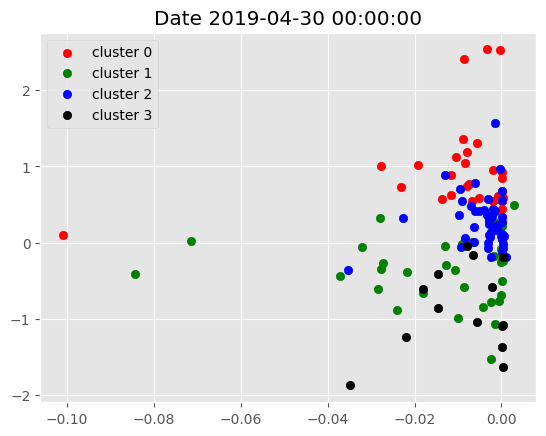

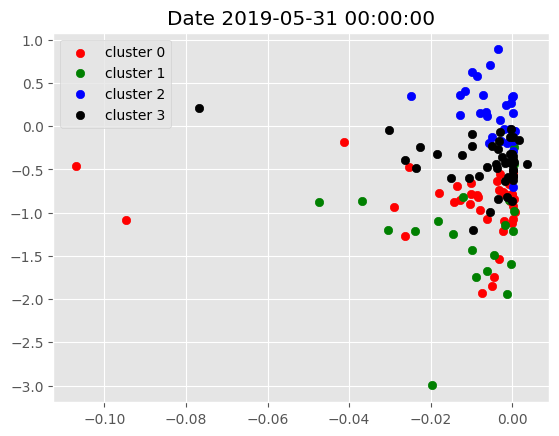

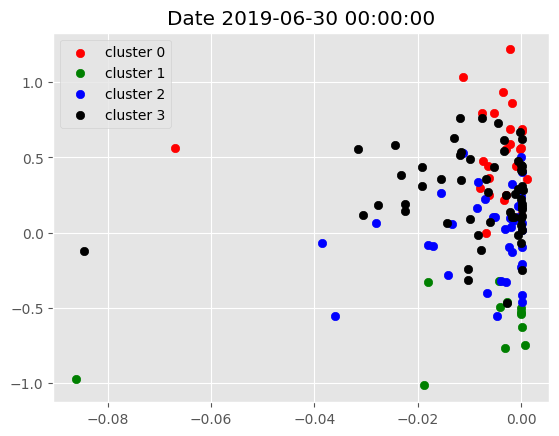

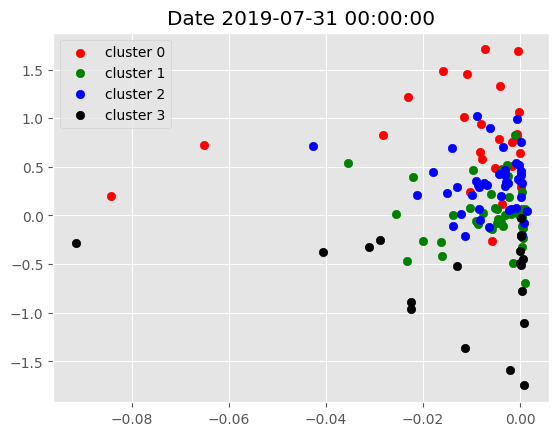

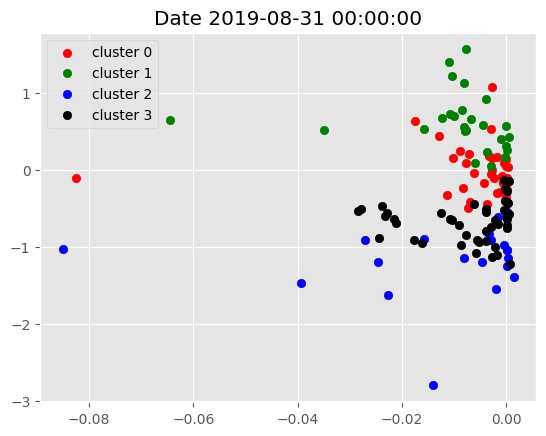

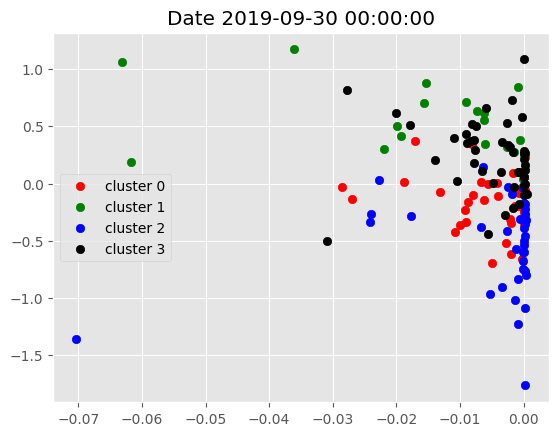

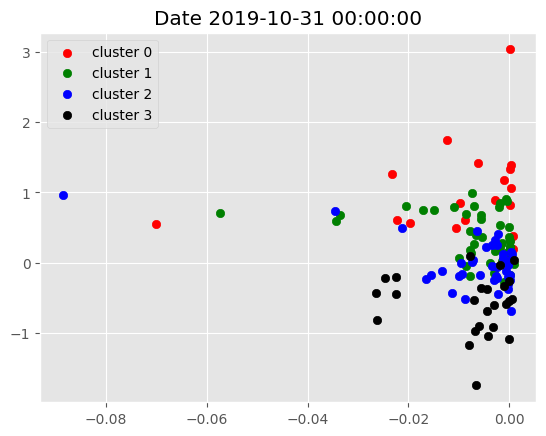

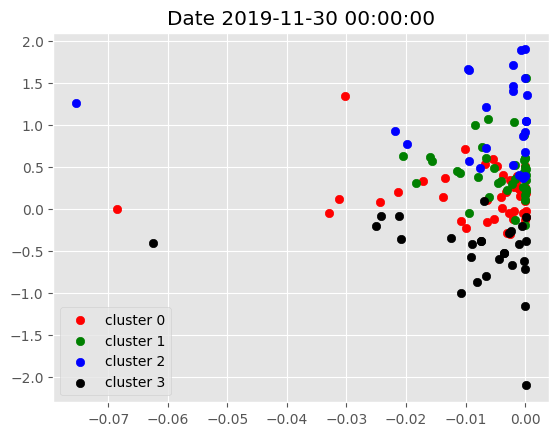

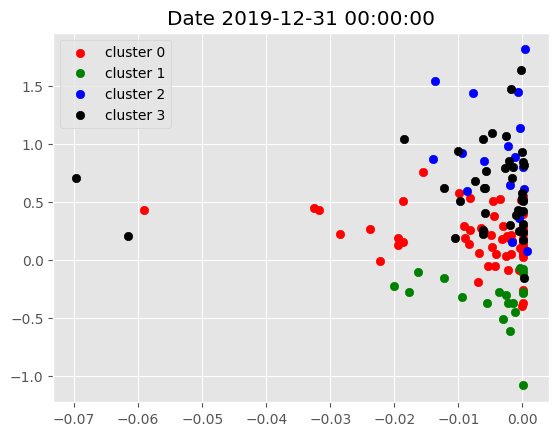

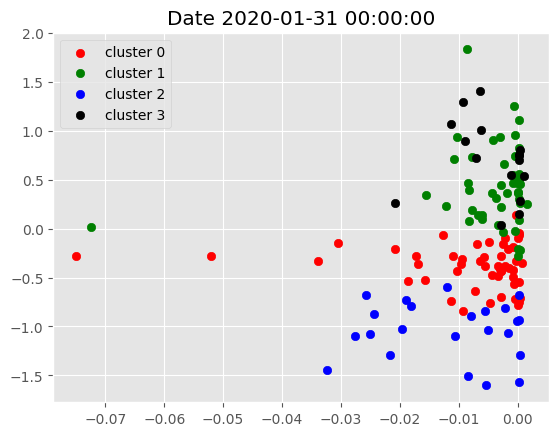

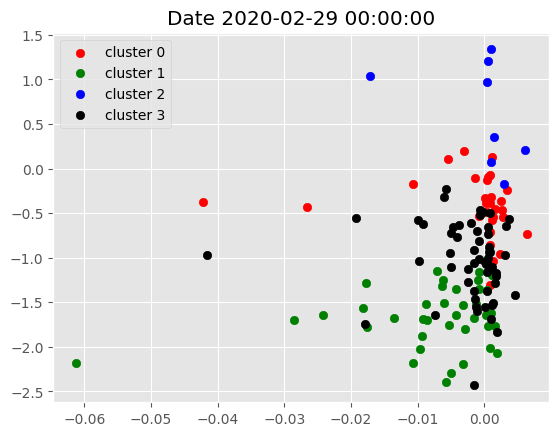

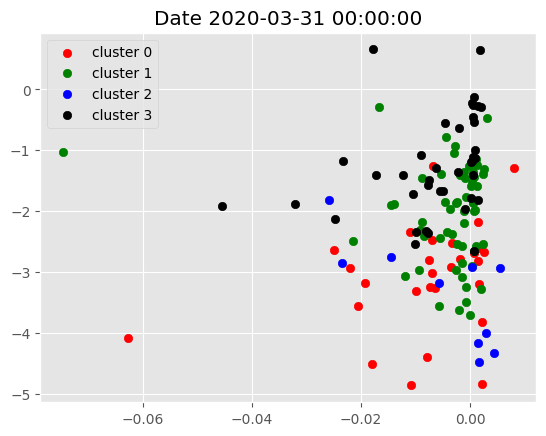

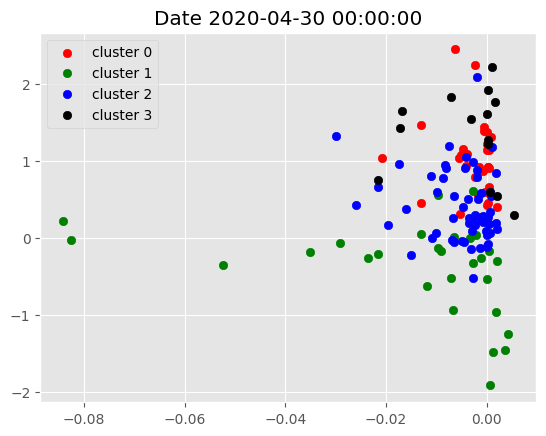

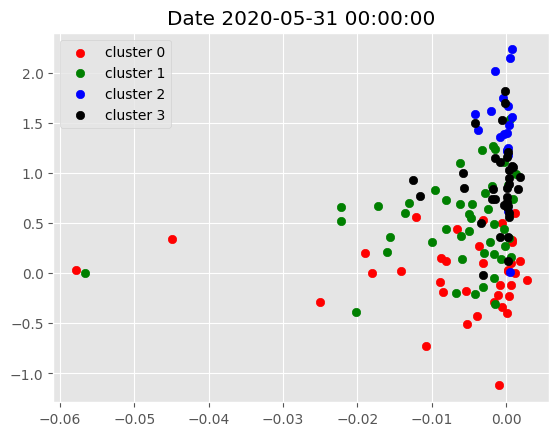

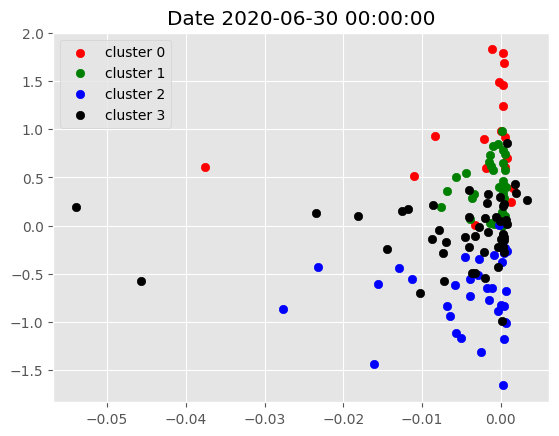

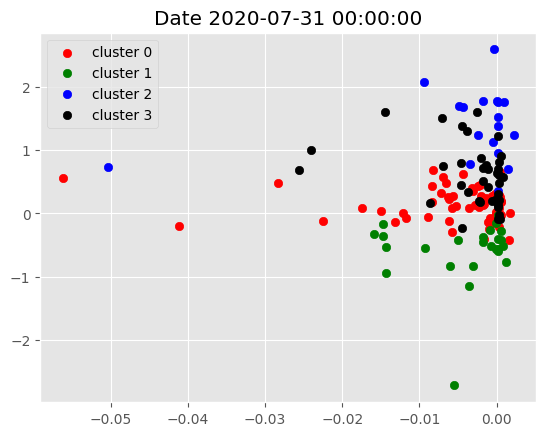

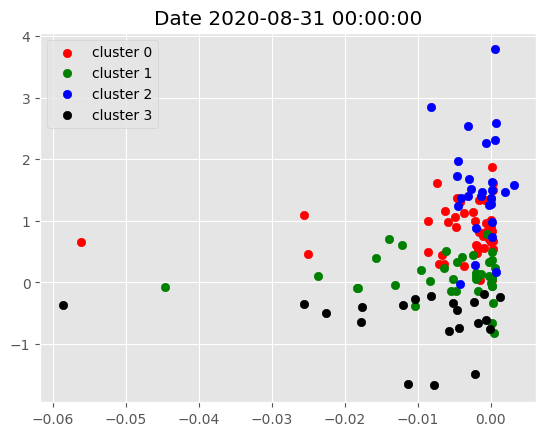

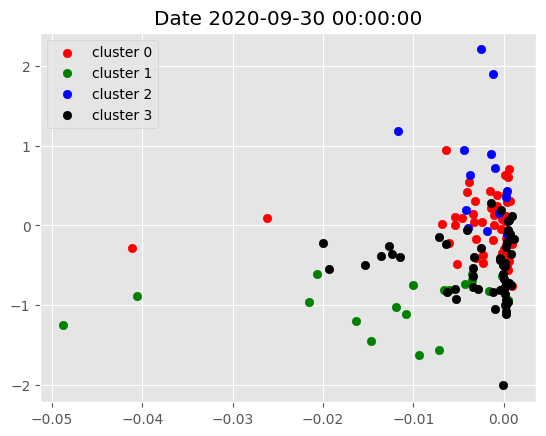

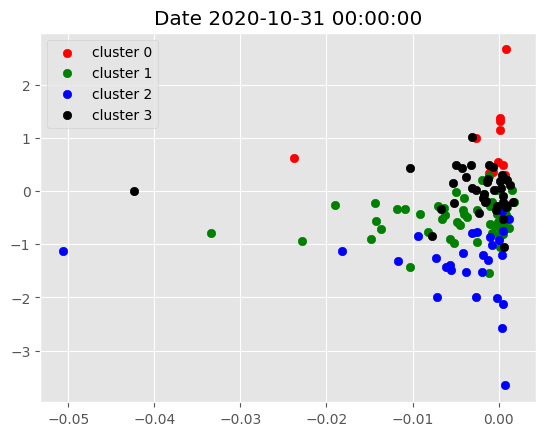

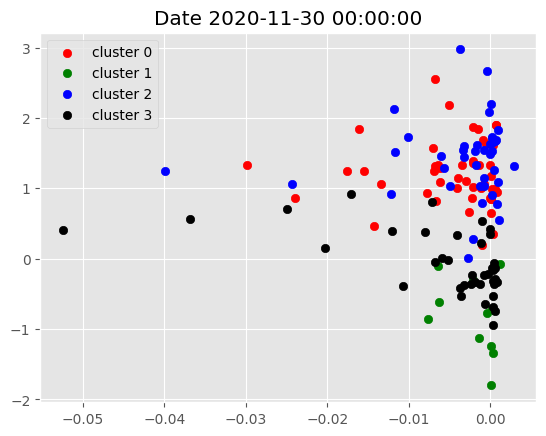

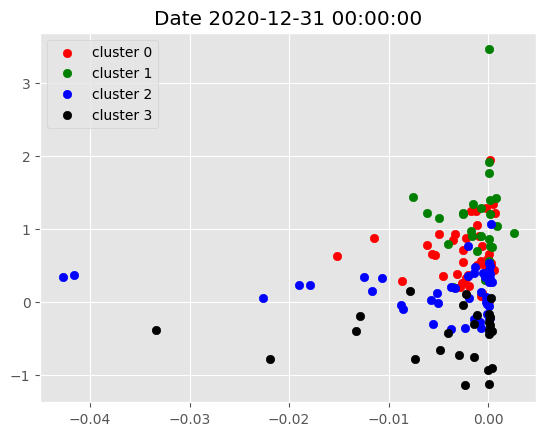

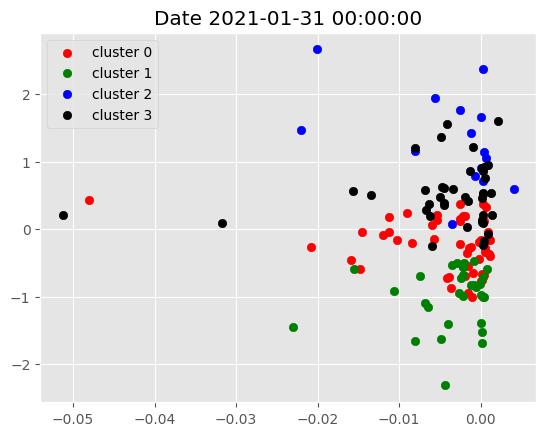

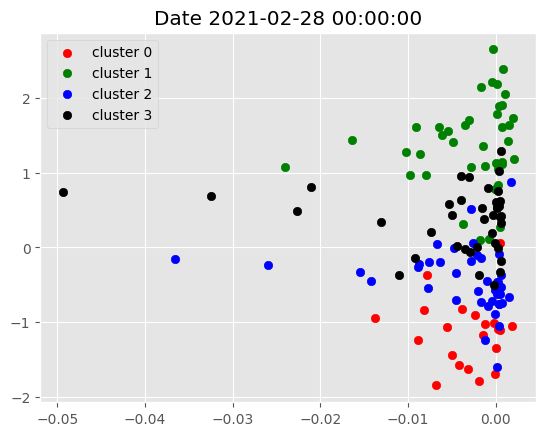

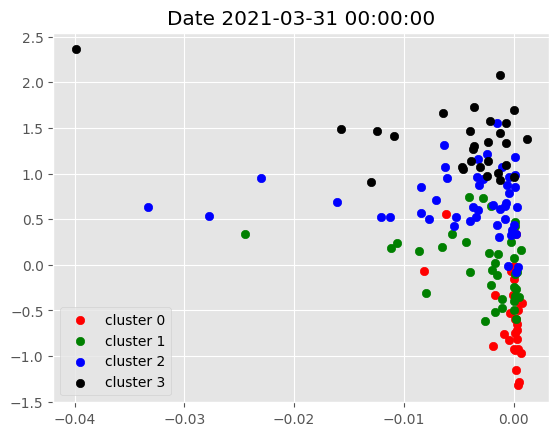

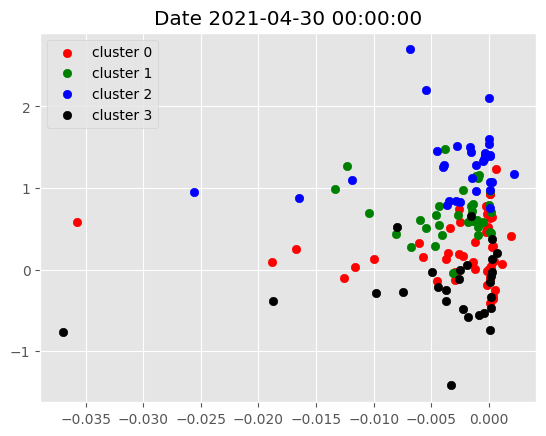

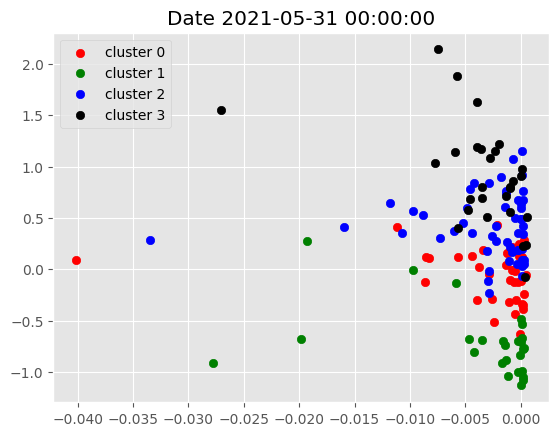

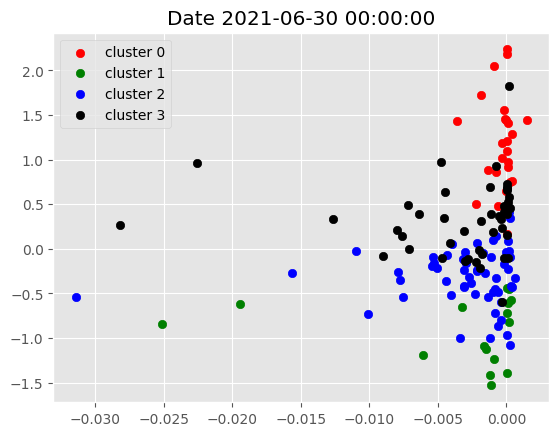

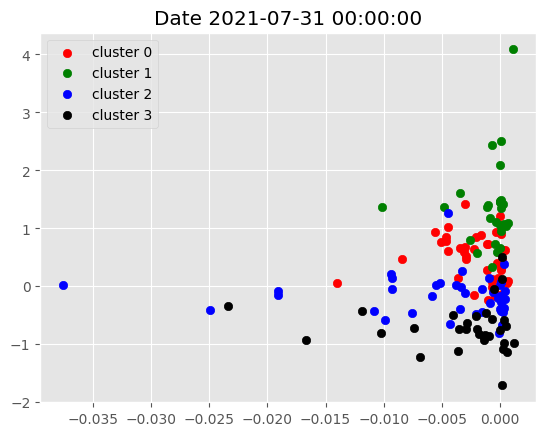

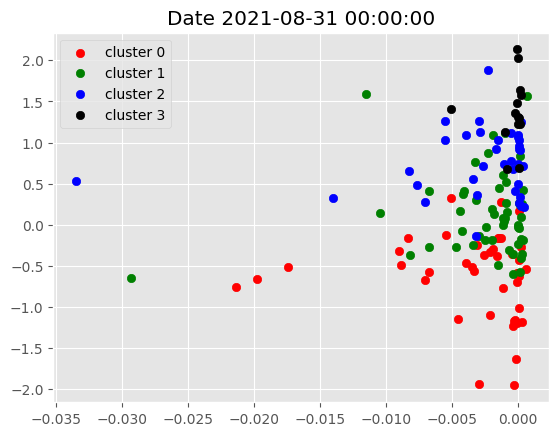

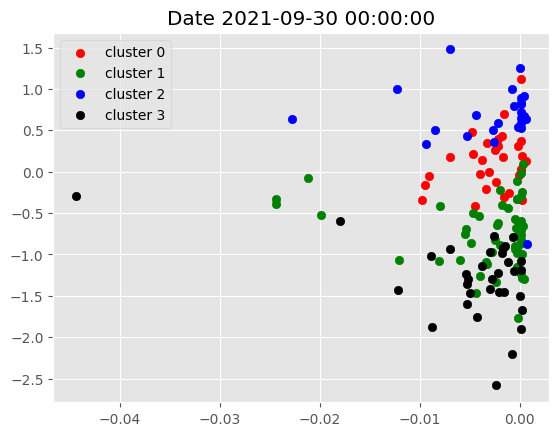

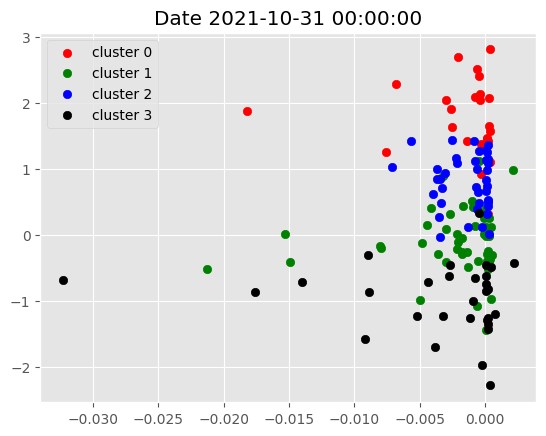

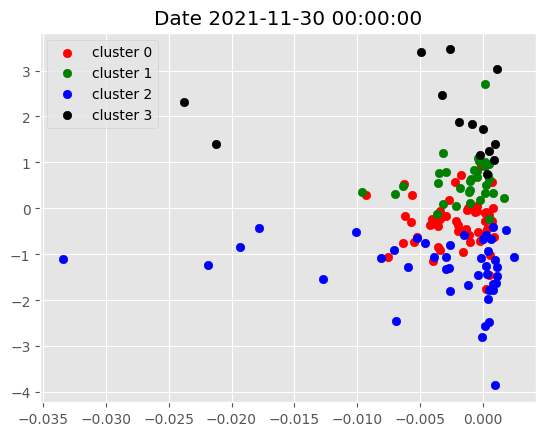

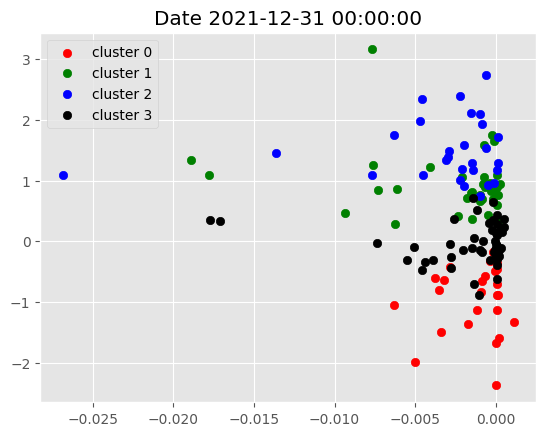

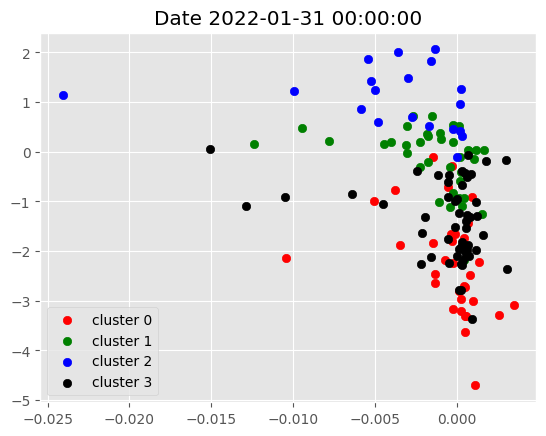

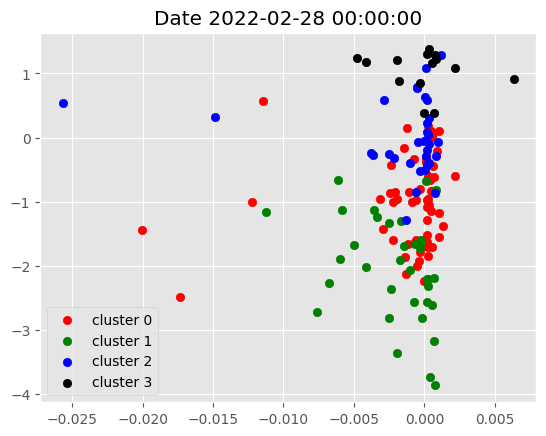

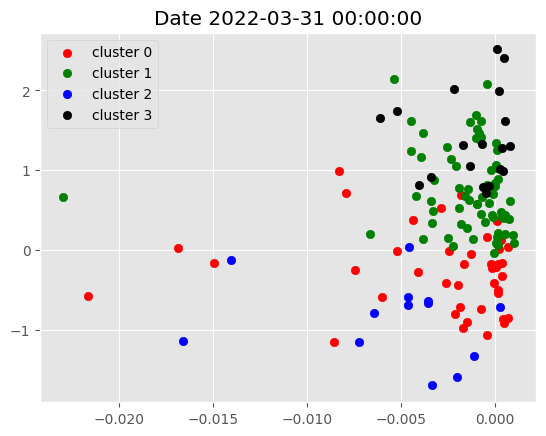

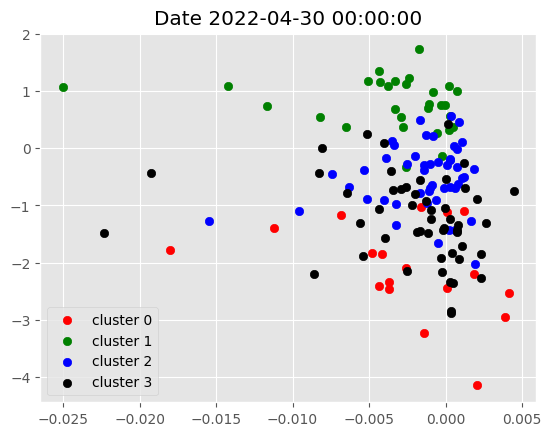

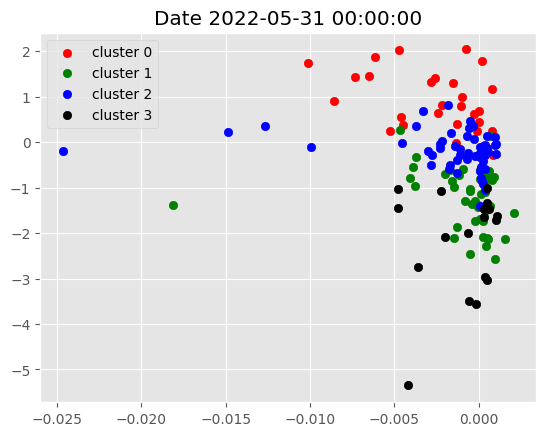

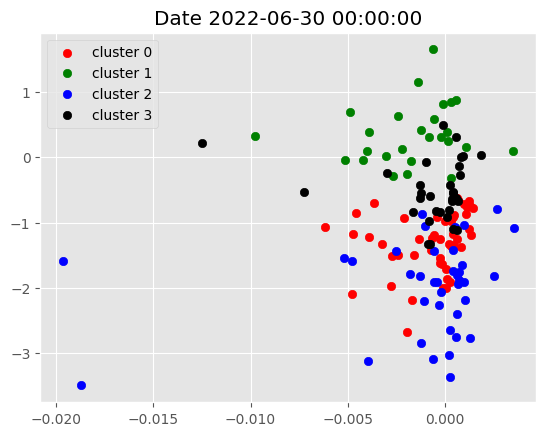

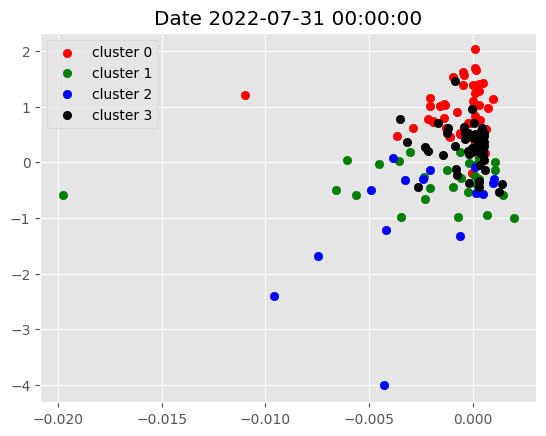

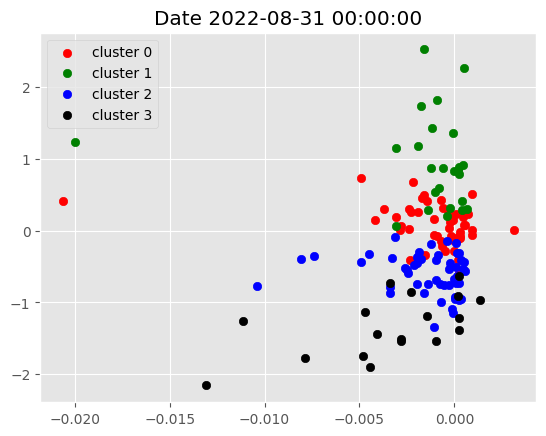

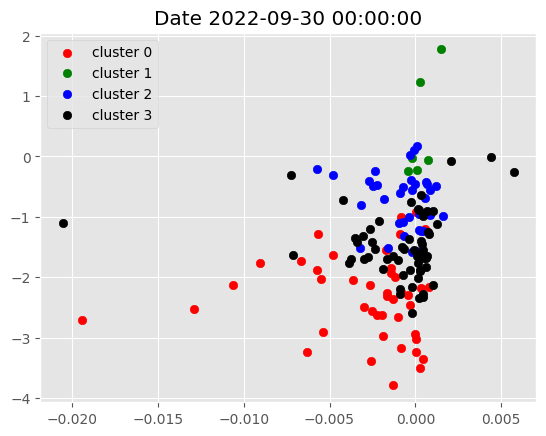

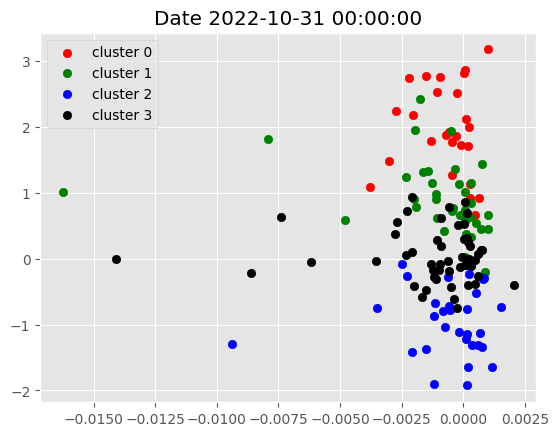

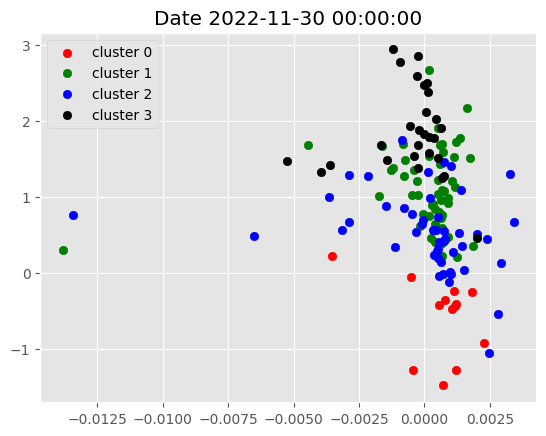

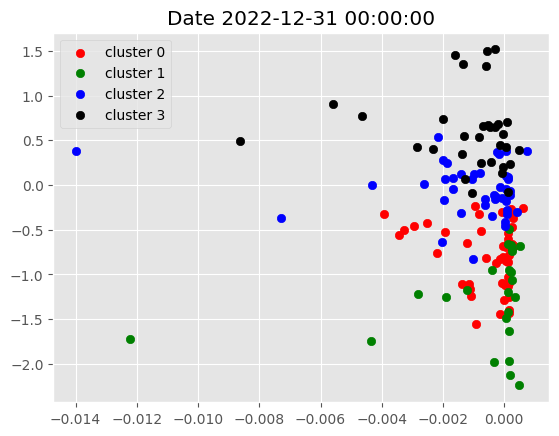

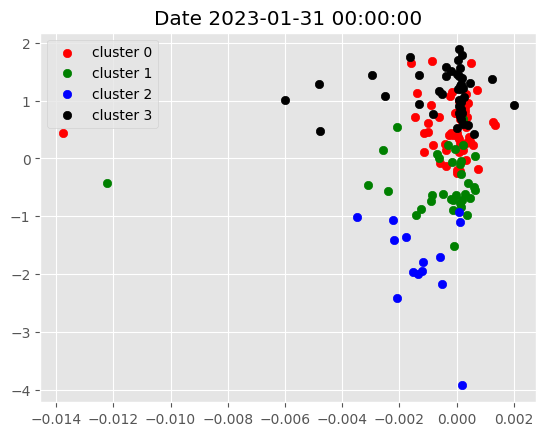

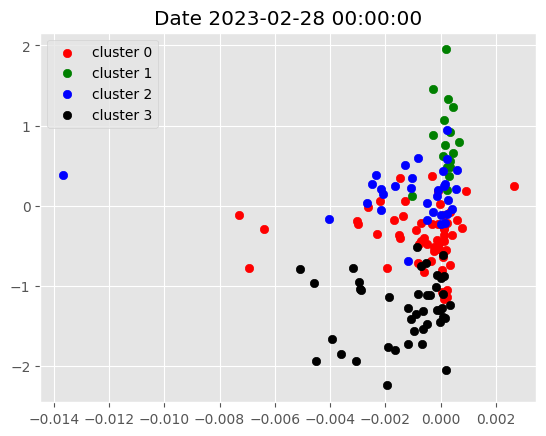

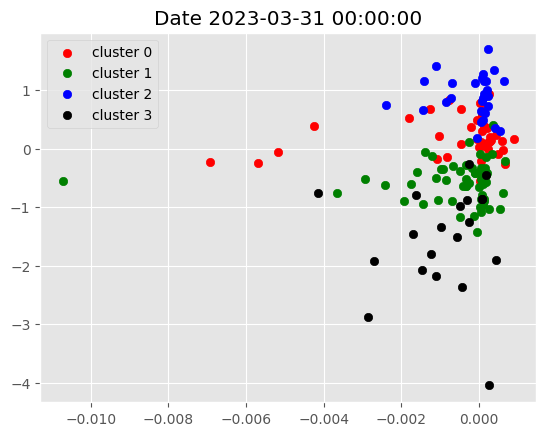

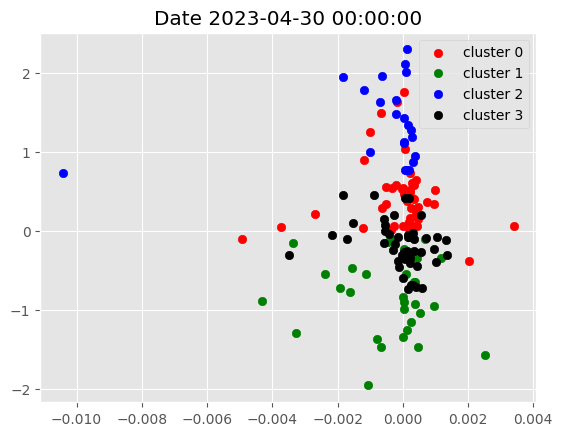

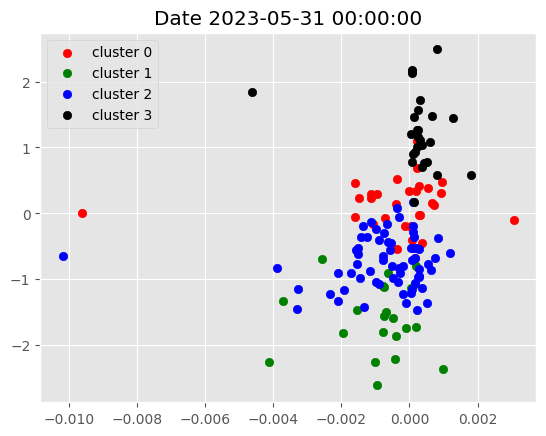

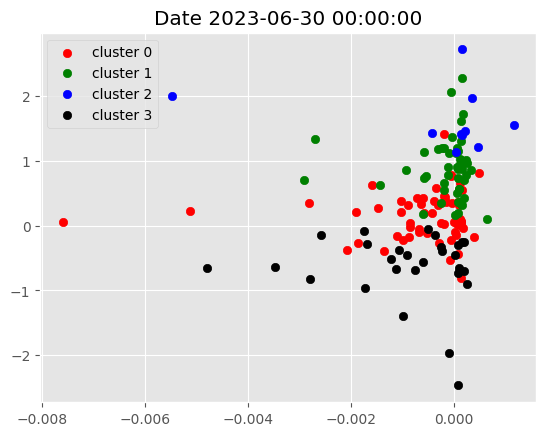

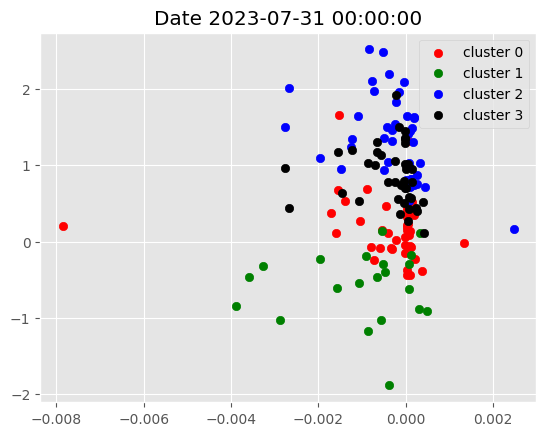

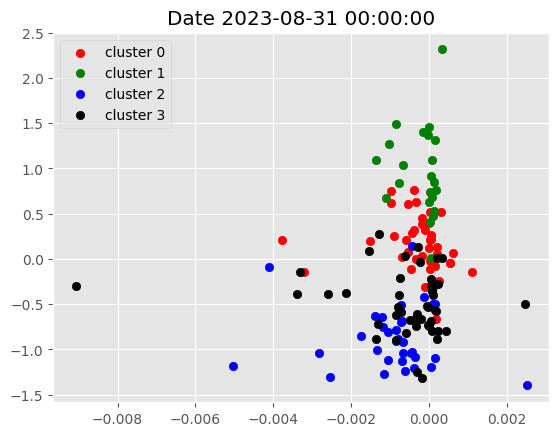

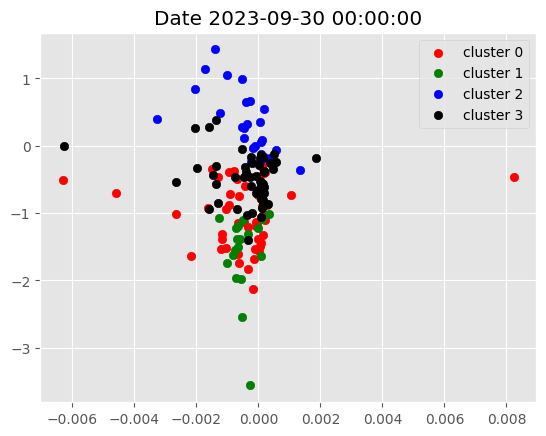

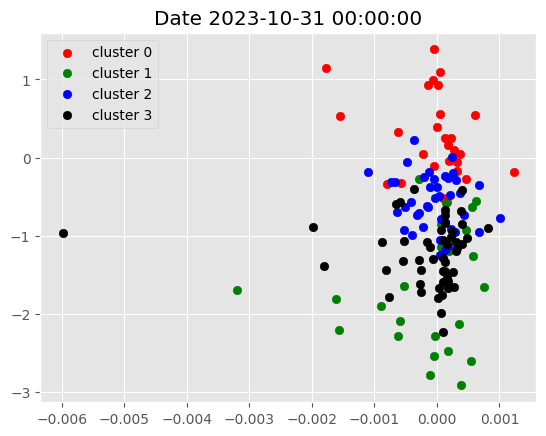

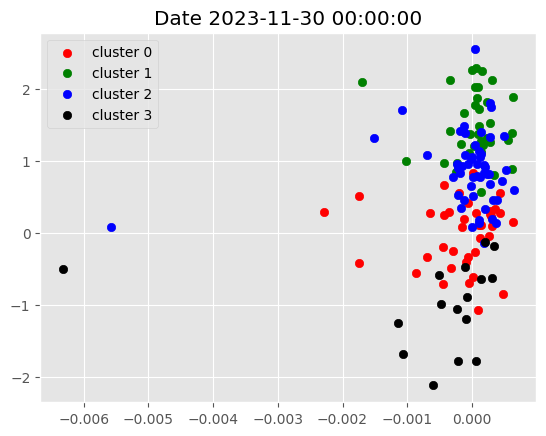

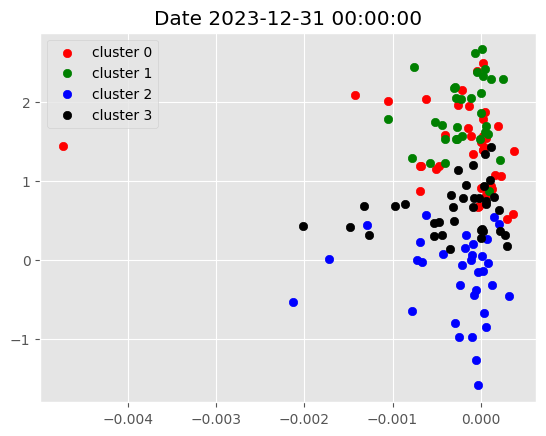

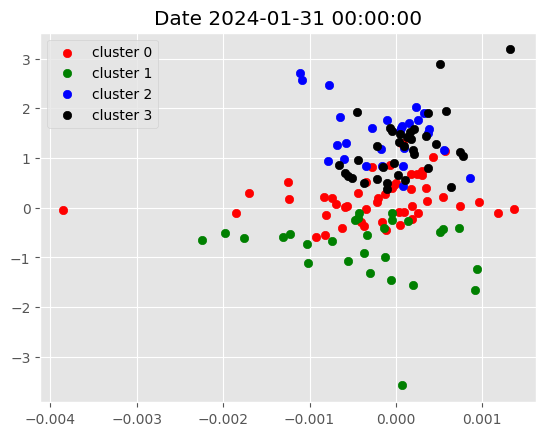

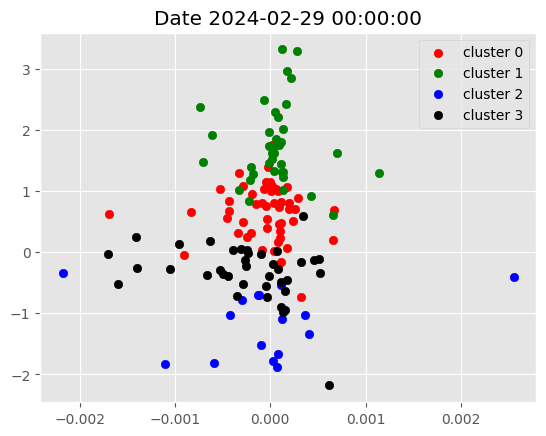

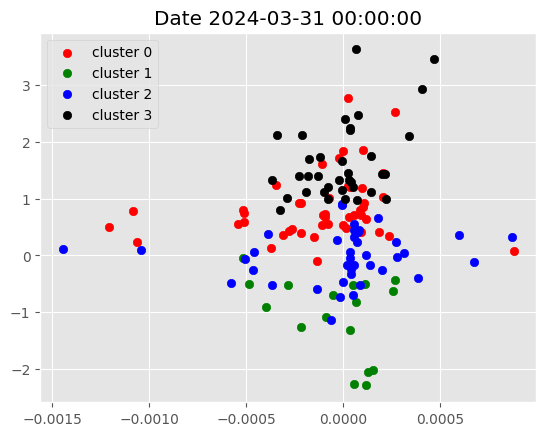

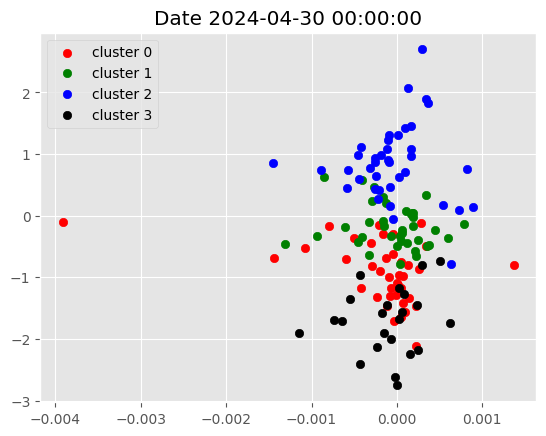

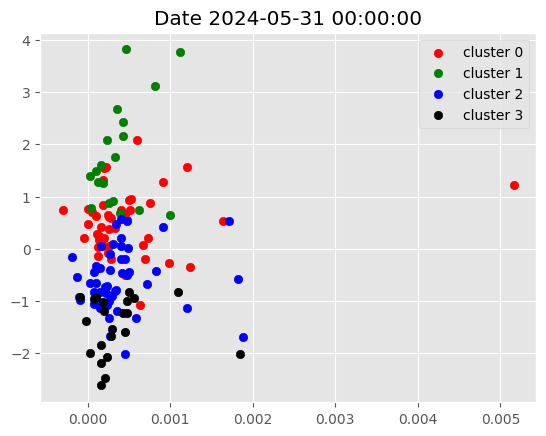

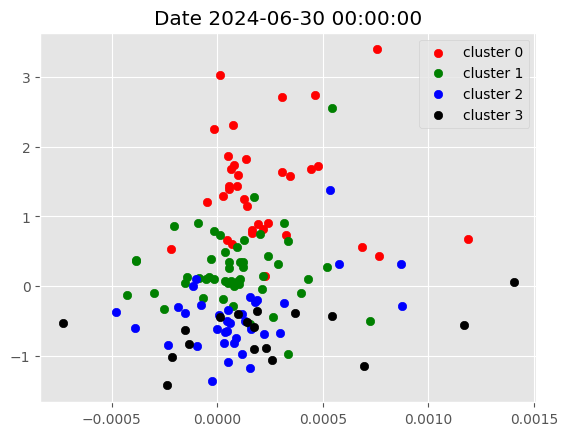

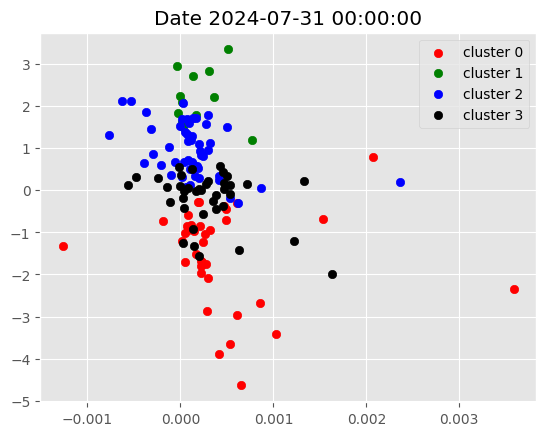

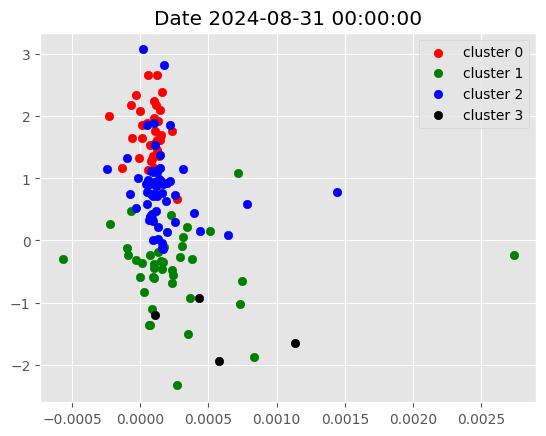

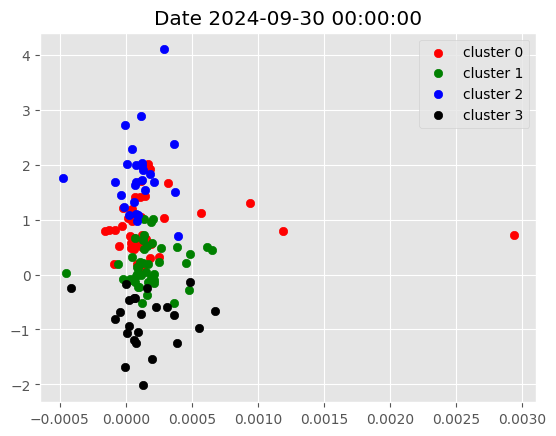

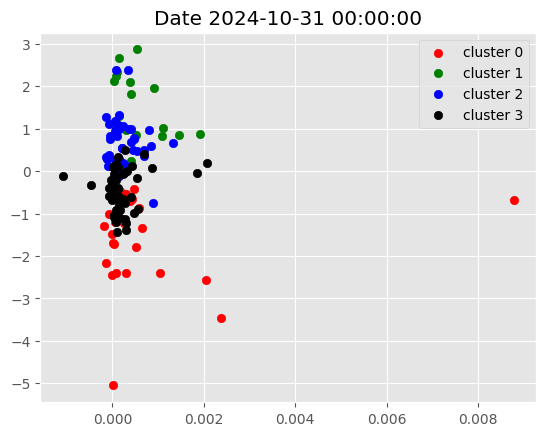

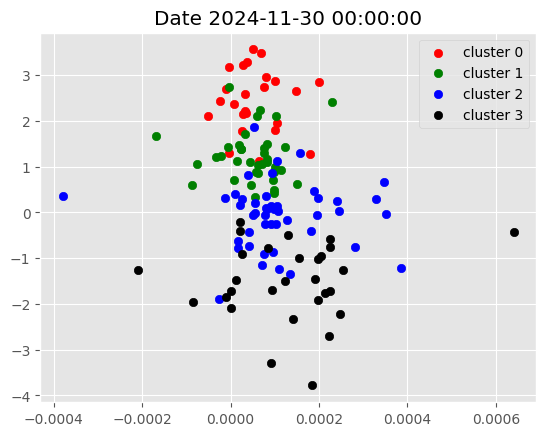

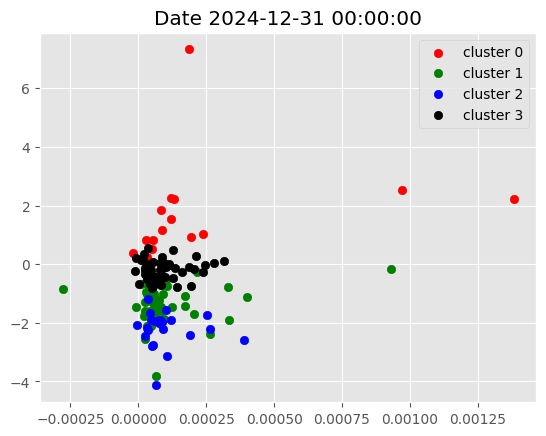

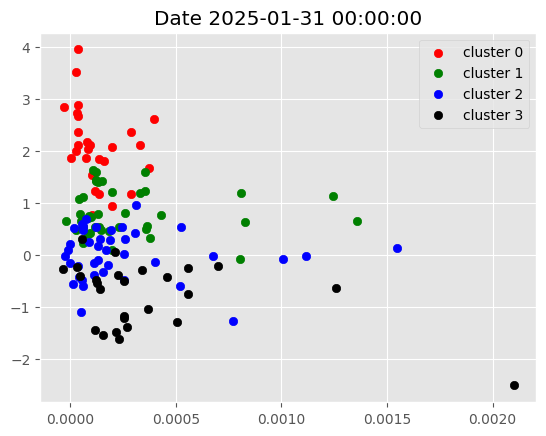

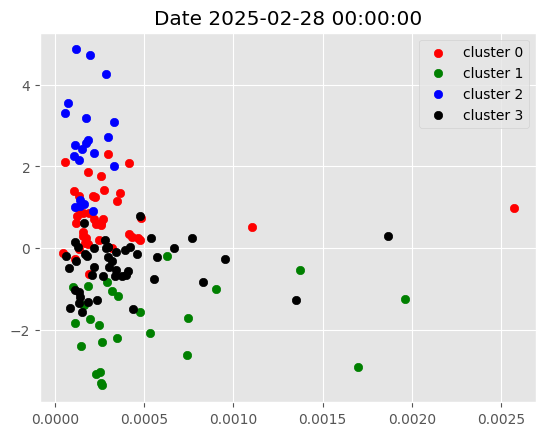

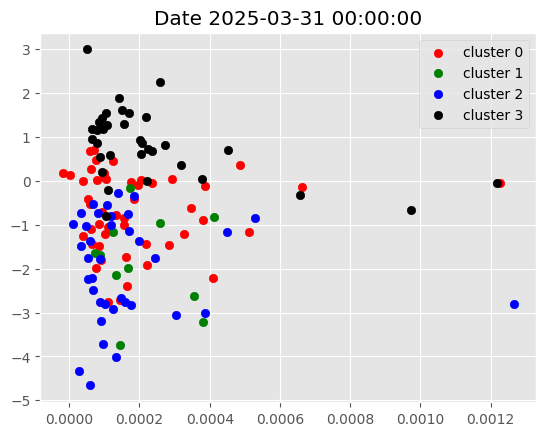

In [50]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():
    
    g = data.xs(i, level=0)
    
    plt.title(f'Date {i}')
    
    plot_clusters(g)

Apply pre-defined centroids.

This code creates initial centroids for K-Means clustering with specific RSI (Relative Strength Index) values while setting all other features to zero.

1. **Define Target RSI Values**:
   - `target_rsi_values = [30, 45, 55, 70]` - Creates a list of four specific RSI values
   - These values are strategically chosen:
     - 30: Traditionally considered "oversold" territory
     - 45: Slightly below the neutral level
     - 55: Slightly above the neutral level
     - 70: Traditionally considered "overbought" territory

2. **Create Empty Centroids Matrix**:
   - `initial_centroids = np.zeros((len(target_rsi_values), 18))` - Creates a matrix of zeros:
     - 4 rows (one for each target RSI value)
     - 18 columns (matching the number of features in the dataset)

3. **Set RSI Values in Centroids**:
   - `initial_centroids[:, 6] = target_rsi_values` - Sets the 7th column (index 6) to the target RSI values
   - This assumes that the RSI feature is in the 7th column of the feature set

4. **Display the Result**:
   - `initial_centroids` - Returns the matrix for inspection

### What This Achieves:

This code creates initial centroids for K-Means clustering that are specifically designed to:

1. **Focus on RSI**: By setting only the RSI values and leaving all other features as zero, the clustering will initially be heavily influenced by the RSI feature

2. **Create Meaningful Clusters**: The chosen RSI values correspond to meaningful levels in technical analysis:
   - Cluster 0 (RSI = 30): Potentially oversold stocks
   - Cluster 1 (RSI = 45): Stocks with slightly bearish momentum
   - Cluster 2 (RSI = 55): Stocks with slightly bullish momentum
   - Cluster 3 (RSI = 70): Potentially overbought stocks

3. **Guide the Algorithm**: Rather than using random initialization, this provides a strategic starting point for the K-Means algorithm

### Technical Significance:

1. **Semi-Supervised Clustering**: This approach is a form of semi-supervised clustering where domain knowledge (RSI thresholds) guides the unsupervised learning process

2. **Feature Importance**: By initializing centroids this way, the algorithm is nudged to consider RSI as an important feature

3. **Interpretable Results**: The resulting clusters are more likely to have a clear interpretation in terms of RSI levels

4. **Stability**: Using fixed initial centroids instead of random initialization makes the clustering results more reproducible

This technique would typically be used with the `init` parameter in K-Means set to a custom value rather than 'random' as seen in the previous code. The correct implementation would be:

In [52]:
target_rsi_values = [30, 45, 55, 70]

initial_centroids = np.zeros((len(target_rsi_values), 18))

initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization

First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.

## Code Explanation: Filtering Data for Cluster 3

This code filters the dataset to include only the rows where the 'cluster' value is 3, creating a subset of the original data.

### Step-by-Step Explanation:

1. **Filter the Data**:
   - `data[data['cluster']==3]` - Creates a boolean mask where 'True' indicates rows where the 'cluster' column equals 3
   - This mask is then used to select only those rows from the original DataFrame

2. **Create a Copy**:
   - `.copy()` - Creates a deep copy of the filtered data
   - This is a good practice to avoid the SettingWithCopyWarning in pandas when you plan to modify the filtered data later

3. **Display the Result**:
   - `filtered_df` - Returns the filtered DataFrame for inspection

### What This Achieves:

This code isolates all data points that were assigned to cluster 3 during the K-Means clustering process. Based on the previous code snippets, cluster 3 likely represents stocks with high RSI values (around 70), potentially indicating overbought conditions.

### Significance of Cluster 3:

From the previous code that set up initial centroids, we can infer that cluster 3 was initialized with an RSI value of 70, which in technical analysis typically indicates:

1. **Overbought Conditions**: Stocks that may have risen too far, too fast
2. **Potential Reversal Candidates**: Stocks that might be due for a pullback or correction
3. **Strong Momentum**: Stocks showing significant upward price momentum

### Practical Applications:

Filtering for cluster 3 could be useful for:

1. **Short-Selling Strategy**: Identifying potential candidates for short positions
2. **Mean Reversion Trading**: Finding stocks that might revert to their mean
3. **Risk Management**: Identifying positions that might be at higher risk of pullback
4. **Portfolio Rebalancing**: Deciding which positions to trim or exit
5. **Further Analysis**: Examining what other characteristics these potentially overbought stocks share

The resulting `filtered_df` DataFrame contains all the original features (technical indicators, factor exposures, etc.) but only for stocks that were classified in cluster 3. This allows for deeper analysis of this specific segment of the market.

In [55]:
filtered_df = data[data['cluster']==3].copy()

filtered_df

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2019-04-30 AMGN           -0.014538  39.861827  4.981122  5.052419  5.123717   
           BIIB            0.000240  35.830006  5.412149  5.451802  5.491455   
           COP            -0.018081  40.087670  3.948739  3.989902  4.031065   
           HAL            -0.006523  38.587650  3.275470  3.339531  3.403593   
           INTC           -0.007839  37.258421  3.818939  3.900182  3.981424   
...                             ...        ...       ...       ...       ...   
2025-03-31 UBER            0.000379  55.790496  4.259971  4.316043  4.372116   
           UNH             0.000093  55.602198  6.119873  6.188327  6.256781   
           VRTX            0.000259  63.387373  6.155402  6.206652  6.257902   
           VZ              0.000096  54.486121  3.760999  3.802040  3.843081   
           XOM             0.000065  60.565056  4.662864  4.717553  4.772242   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2019-04-30 AMGN   -0.776274 -0.856208  -0.056111  -0.028716  -0.011540   
           BIIB   -0.073289 -1.625368  -0.030206  -0.161840  -0.117713   
           COP    -0.842091 -0.601604  -0.054240  -0.035486  -0.021555   
           HAL    -0.713171 -0.164127  -0.033106  -0.036415  -0.031424   
           INTC    0.171935 -0.038726  -0.049534  -0.018294   0.029161   
...                     ...       ...        ...        ...        ...   
2025-03-31 UBER    2.207342  0.037586   0.006578   0.069814   0.082478   
           UNH     1.248706  0.194206   0.092107  -0.022166   0.008395   
           VRTX    2.385962  2.243846   0.066592   0.052820   0.083152   
           VZ      0.702822  1.178491   0.010673   0.051601   0.034955   
           XOM     0.990915  1.189121   0.040151   0.045782   0.027925   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2019-04-30 AMGN    -0.009582  -0.007781    0.004719  0.707537 -0.055283   
           BIIB    -0.046095  -0.041075   -0.014633  0.043927  0.287033   
           COP     -0.016118  -0.013821   -0.001671  1.256645 -0.332493   
           HAL     -0.031279  -0.042153   -0.049272  2.602583  0.348286   
           INTC     0.016402   0.008702    0.001093  1.027761  0.313365   
...                      ...        ...         ...       ...       ...   
2025-03-31 UBER     0.002971   0.005722   -0.000521  1.362631  0.300819   
           UNH     -0.019131   0.002865    0.004928  0.542129 -0.100218   
           VRTX     0.016062   0.009805    0.017002  0.501478  0.011235   
           VZ       0.000422   0.011625    0.008601  0.476227 -0.498374   
           XOM      0.000817   0.003450    0.002453  0.972606 -0.021372   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2019-04-30 AMGN    0.001540  0.599733  0.956521        3  
           BIIB   -0.656443  0.038368  0.554759        3  
           COP     1.461881 -1.277524  0.010778        3  
           HAL     1.159660 -0.979035  0.164480        3  
           INTC   -0.258879  0.263213  0.671214        3  
...                     ...       ...       ...      ...  
2025-03-31 UBER   -0.206242 -1.995862 -0.607680        3  
           UNH     0.055434  0.497636  0.085937        3  
           VRTX   -0.660575  0.423964  0.819050        3  
           VZ      0.339315  0.124624  0.047062        3  
           XOM     0.952718 -0.449745  0.321863        3  

[2489 rows x 19 columns]

Preparing Trading Dates and Tickers

This code processes the filtered cluster data to create a dictionary mapping dates to lists of tickers for potential trading.

### Step-by-Step Explanation:

1. **Print Initial Data**:
   - `print(filtered_df)` - Displays the filtered DataFrame (cluster 3 stocks)

2. **Reset Ticker Level in Index**:
   - `filtered_df = filtered_df.reset_index(level=1)` - Moves the 'ticker' from the index to a regular column
   - The index now contains only the date

3. **Shift Dates Forward**:
   - `filtered_df.index = filtered_df.index+pd.DateOffset(1)` - Adds one day to all dates in the index
   - This is crucial for trading strategies - it shifts from analysis date to execution date
   - Prevents look-ahead bias by ensuring we trade based on previous day's signals

4. **Reconstruct MultiIndex**:
   - `filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])` - Resets the index completely, then sets a new MultiIndex with date and ticker
   - This reorganizes the data with the shifted dates

5. **Extract Unique Dates**:
   - `dates = filtered_df.index.get_level_values('date').unique().tolist()` - Gets a list of all unique dates in the index

6. **Create Date-to-Tickers Dictionary**:
   - Initializes an empty dictionary `fixed_dates`
   - Loops through each date:
     - Converts the date to string format 'YYYY-MM-DD'
     - For each date, extracts the list of tickers from that date
     - Stores this mapping in the dictionary

### What This Achieves:

This code creates a trading calendar and stock selection system:

1. **Forward-Shifted Signals**: By adding one day to the dates, the code ensures that trading decisions are based on information available the previous day, avoiding look-ahead bias

2. **Trading Calendar**: The `fixed_dates` dictionary maps each trading date to the specific stocks that should be traded on that date

3. **Implementation-Ready Format**: The dictionary format makes it easy to implement a trading strategy:

4. **Cluster-Based Stock Selection**: Since this is based on the filtered cluster 3 data, it represents a strategy of trading stocks with specific characteristics (likely high RSI/potentially overbought stocks)

In [56]:
print(filtered_df)

filtered_df = filtered_df.reset_index(level=1)

#print(filtered_df)

filtered_df.index = filtered_df.index+pd.DateOffset(1)
#print(filtered_df.index)

filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

#print(filtered_df)

dates = filtered_df.index.get_level_values('date').unique().tolist()

#print(dates)

fixed_dates = {}

for d in dates:
    
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
    
#fixed_dates # want these below stock to trade for that dates so now can create our portfolio

                   garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2019-04-30 AMGN           -0.014538  39.861827  4.981122  5.052419  5.123717   
           BIIB            0.000240  35.830006  5.412149  5.451802  5.491455   
           COP            -0.018081  40.087670  3.948739  3.989902  4.031065   
           HAL            -0.006523  38.587650  3.275470  3.339531  3.403593   
           INTC           -0.007839  37.258421  3.818939  3.900182  3.981424   
...                             ...        ...       ...       ...       ...   
2025-03-31 UBER            0.000379  55.790496  4.259971  4.316043  4.372116   
           UNH             0.000093  55.602198  6.119873  6.188327  6.256781   
           VRTX            0.000259  63.387373  6.155402  6.206652  6.257902   
           VZ              0.000096  54.486121  3.760999  3.802040  3.843081   
           XOM             0.000065  60.

Define portfolio optimization function

This code defines a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the Sharpe ratio.

To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

Apply signle stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).

In [59]:
# The core optimization engine from PyPortfolioOpt
from pypfopt.efficient_frontier import EfficientFrontier
# Contains functions to estimate risk (covariance matrices)
from pypfopt import risk_models
# Contains functions to estimate expected returns
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):
    
    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)
    
    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)
    
    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')
    
    weights = ef.max_sharpe()
    
    return ef.clean_weights() # Produces Clean, Implementable Weights

Download Fresh Daily Prices Data only for short listed stocks.

In [61]:
data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),

(Timestamp('2018-04-30 00:00:00'),)

In [62]:
stocks = data.index.get_level_values('ticker').unique().tolist()

In [63]:
new_df = yf.download(tickers=stocks, auto_adjust=False,
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1])

#new_df.index.name = 'Date'
print('new_df.columns' , new_df.columns)
print(new_df.index)
new_df.head()

[*********************100%***********************]  154 of 154 completed


new_df.columns MultiIndex([('Adj Close', 'AAPL'),
            ('Adj Close', 'ABBV'),
            ('Adj Close', 'ABNB'),
            ('Adj Close',  'ABT'),
            ('Adj Close',  'ACN'),
            ('Adj Close', 'ADBE'),
            ('Adj Close',  'ADI'),
            ('Adj Close',  'ADP'),
            ('Adj Close', 'ADSK'),
            ('Adj Close', 'ALGN'),
            ...
            (   'Volume',  'VLO'),
            (   'Volume', 'VRTX'),
            (   'Volume',   'VZ'),
            (   'Volume',  'WBA'),
            (   'Volume', 'WDAY'),
            (   'Volume',  'WDC'),
            (   'Volume',  'WFC'),
            (   'Volume',  'WMT'),
            (   'Volume', 'WYNN'),
            (   'Volume',  'XOM')],
           names=['Price', 'Ticker'], length=924)
DatetimeIndex(['2018-04-30', '2018-05-01', '2018-05-02', '2018-05-03',
               '2018-05-04', '2018-05-07', '2018-05-08', '2018-05-09',
               '2018-05-10', '2018-05-11',
               ...
              

Price       Adj Close                                                     \
Ticker           AAPL       ABBV ABNB        ABT         ACN        ADBE   
Date                                                                       
2018-04-30  38.993221  71.553284  NaN  51.687744  137.482712  221.600006   
2018-05-01  39.899273  75.644150  NaN  52.301262  138.137375  224.080002   
2018-05-02  41.661842  74.384293  NaN  51.438759  137.037109  221.100006   
2018-05-03  41.737339  74.317581  NaN  51.509899  137.964600  226.050003   
2018-05-04  43.374828  74.236053  NaN  52.230133  139.519485  228.509995   

Price                                                                        \
Ticker            ADI         ADP        ADSK        ALGN       AMAT    AMD   
Date                                                                          
2018-04-30  76.625893  101.935013  125.900002  249.850006  45.789173  10.88   
2018-05-01  77.950478  102.556564  127.059998  251.339996  46.932278  11.13   
2018-05-02  77.459251  105.370827  125.260002  249.470001  46.581978  10.97   
2018-05-03  77.117149  106.268623  127.599998  255.139999  46.747910  10.93   
2018-05-04  79.187370  108.219635  129.460007  258.970001  48.453362  11.28   

Price                                                                \
Ticker            AMGN         AMT       AMZN       AVGO        AXP   
Date                                                                  
2018-04-30  141.133331  115.589973  78.306503  18.532492  89.696228   
2018-05-01  136.927155  114.521912  79.112999  18.610043  89.541786   
2018-05-02  137.048462  115.683212  78.484001  18.477558  88.678894   
2018-05-03  134.589478  116.624130  78.603996  18.195642  88.233826   
2018-05-04  135.875595  117.700706  79.047501  18.621349  89.332901   

Price                                                                  \
Ticker             AZO          BA        BAC         BDX        BIIB   
Date                                                                    
2018-04-30  624.520020  319.449432  25.303093  204.930664  273.600006   
2018-05-01  632.159973  315.599548  25.328465  206.556885  274.609985   
2018-05-02  630.179993  310.475861  25.015558  203.445877  274.130005   
2018-05-03  636.849976  316.700897  24.694195  200.741348  266.440002   
2018-05-04  649.940002  320.282654  24.778761  198.558304  270.339996   

Price                                                                  \
Ticker             BKNG         BLK        BMY       BRK-B        BSX   
Date                                                                    
2018-04-30  2154.445068  435.608490  40.774033  193.729996  28.719999   
2018-05-01  2155.819824  432.659882  41.212048  195.110001  29.480000   
2018-05-02  2126.569824  430.003571  40.281288  193.309998  29.270000   
2018-05-03  2128.933838  427.397491  40.242168  191.610001  29.430000   
2018-05-04  2152.179932  434.689697  40.148304  195.639999  29.549999   

Price                                                                 \
Ticker              C         CAT        CCL        CHTR          CI   
Date                                                                   
2018-04-30  53.512367  123.775459  58.421764  271.290009  159.564026   
2018-05-01  53.496700  123.826874  59.394531  279.399994  158.867523   
2018-05-02  53.292892  123.346695  58.227203  274.779999  160.065521   
2018-05-03  53.253708  123.278114  58.644115  271.359985  160.548431   
2018-05-04  53.505726  125.498795  58.894249  276.070007  158.960403   

Price                                                                  \
Ticker          CMCSA     CMG        COP        COST         CRM CRWD   
Date                                                                    
2018-04-30  26.385880  8.4666  52.145927  177.849136  120.317963  NaN   
2018-05-01  26.949068  8.5202  52.313110  177.298859  122.426193  NaN   
2018-05-02  26.310223  8.4244  52.106117  174.998657  122.137810  NaN   
2018

Calculate daily returns for each stock which could land up in our portfolio.

Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

Calculated each day portfolio return.

weights = optimize_weights(prices=optimization_df,
                                   lower_bound=round(1/(len(optimization_df.columns)*2),3))

weights

optimization_df = new_df['Adj Close'][optimization_start_date:optimization_end_date][cols]
optimization_df

round(1/(len(optimization_df.columns)*2),2)

In [68]:
print(start_date)
print(end_date)

2017-03-27 00:00:00
2025-03-25


In [69]:
new_df.head()

Price       Adj Close                                                     \
Ticker           AAPL       ABBV ABNB        ABT         ACN        ADBE   
Date                                                                       
2018-04-30  38.993221  71.553284  NaN  51.687744  137.482712  221.600006   
2018-05-01  39.899273  75.644150  NaN  52.301262  138.137375  224.080002   
2018-05-02  41.661842  74.384293  NaN  51.438759  137.037109  221.100006   
2018-05-03  41.737339  74.317581  NaN  51.509899  137.964600  226.050003   
2018-05-04  43.374828  74.236053  NaN  52.230133  139.519485  228.509995   

Price                                                                        \
Ticker            ADI         ADP        ADSK        ALGN       AMAT    AMD   
Date                                                                          
2018-04-30  76.625893  101.935013  125.900002  249.850006  45.789173  10.88   
2018-05-01  77.950478  102.556564  127.059998  251.339996  46.932278  11.13   
2018-05-02  77.459251  105.370827  125.260002  249.470001  46.581978  10.97   
2018-05-03  77.117149  106.268623  127.599998  255.139999  46.747910  10.93   
2018-05-04  79.187370  108.219635  129.460007  258.970001  48.453362  11.28   

Price                                                                \
Ticker            AMGN         AMT       AMZN       AVGO        AXP   
Date                                                                  
2018-04-30  141.133331  115.589973  78.306503  18.532492  89.696228   
2018-05-01  136.927155  114.521912  79.112999  18.610043  89.541786   
2018-05-02  137.048462  115.683212  78.484001  18.477558  88.678894   
2018-05-03  134.589478  116.624130  78.603996  18.195642  88.233826   
2018-05-04  135.875595  117.700706  79.047501  18.621349  89.332901   

Price                                                                  \
Ticker             AZO          BA        BAC         BDX        BIIB   
Date                                                                    
2018-04-30  624.520020  319.449432  25.303093  204.930664  273.600006   
2018-05-01  632.159973  315.599548  25.328465  206.556885  274.609985   
2018-05-02  630.179993  310.475861  25.015558  203.445877  274.130005   
2018-05-03  636.849976  316.700897  24.694195  200.741348  266.440002   
2018-05-04  649.940002  320.282654  24.778761  198.558304  270.339996   

Price                                                                  \
Ticker             BKNG         BLK        BMY       BRK-B        BSX   
Date                                                                    
2018-04-30  2154.445068  435.608490  40.774033  193.729996  28.719999   
2018-05-01  2155.819824  432.659882  41.212048  195.110001  29.480000   
2018-05-02  2126.569824  430.003571  40.281288  193.309998  29.270000   
2018-05-03  2128.933838  427.397491  40.242168  191.610001  29.430000   
2018-05-04  2152.179932  434.689697  40.148304  195.639999  29.549999   

Price                                                                 \
Ticker              C         CAT        CCL        CHTR          CI   
Date                                                                   
2018-04-30  53.512367  123.775459  58.421764  271.290009  159.564026   
2018-05-01  53.496700  123.826874  59.394531  279.399994  158.867523   
2018-05-02  53.292892  123.346695  58.227203  274.779999  160.065521   
2018-05-03  53.253708  123.278114  58.644115  271.359985  160.548431   
2018-05-04  53.505726  125.498795  58.894249  276.070007  158.960403   

Price                                                                  \
Ticker          CMCSA     CMG        COP        COST         CRM CRWD   
Date                                                                    
2018-04-30  26.385880  8.4666  52.145927  177.849136  120.317963  NaN   
2018-05-01  26.949068  8.5202  52.313110  177.298859  122.426193  NaN   
2018-05-02  26.310223  8.4244  52.106117  174.998657  122.137810  NaN   
2018

temp_df = returns_dataframe['2018-05-01':'2018-05-30']


#temp_df = temp_df.reset_index()
temp_df = temp_df.stack().to_frame('return').reset_index(level=0)\
    .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
           left_index=True,
            right_index=True)\
.reset_index().set_index(['Date', 'Ticker']).unstack().stack()


print(temp_df)

temp_df.index.names = ['date', 'ticker']
temp_df['weighted_return'] = temp_df['return']*temp_df['weight']

temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')

portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

print(temp_df.columns)
print(temp_df.index)

print('portfolio_df->', portfolio_df)

Portfolio Backtesting Implementation

This code implements a backtesting framework for a trading strategy based on the previously identified cluster stocks. It optimizes portfolio weights for each trading period and calculates the resulting returns.

### What This Achieves:

This code implements a complete portfolio backtesting framework that:

1. **Uses Dynamic Stock Selection**: Trades different stocks on different dates based on the cluster analysis

2. **Implements Smart Portfolio Construction**: Optimizes weights to maximize risk-adjusted returns

3. **Handles Edge Cases**: Falls back to equal weights if optimization fails

4. **Calculates Period Returns**: Tracks the performance of the strategy over time

5. **Manages Realistic Constraints**:
   - Uses only historical data for optimization (no look-ahead bias)
   - Enforces minimum and maximum position sizes
   - Rebalances at regular intervals

The resulting `portfolio_df` contains the daily returns of the strategy, which can be used to:
- Calculate cumulative performance
- Analyze risk metrics (volatility, drawdowns, etc.)
- Compare to benchmarks
- Evaluate the effectiveness of the cluster-based stock selection approach

In [71]:
# Computes daily log returns from adjusted close prices
returns_dataframe = np.log(new_df['Adj Close']).diff()

# Creates an empty DataFrame to store strategy returns
portfolio_df = pd.DataFrame()
for start_date in fixed_dates.keys(): # Loop Through Trading Dates

    # Sets the end of the holding period to the end of the month
    end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')
    # Gets the list of tickers to trade for this date
    cols = fixed_dates[start_date]

    # Sets lookback period start (12 months before trading)
    optimization_start_date = (pd.to_datetime(start_date)-pd.DateOffset(months=12)).strftime('%Y-%m-%d')

    # Sets lookback period end (day before trading)
    optimization_end_date = (pd.to_datetime(start_date)-pd.DateOffset(days=1)).strftime('%Y-%m-%d')

    #  Gets historical prices for the selected stocks during the lookback period
    optimization_df = new_df['Adj Close'][optimization_start_date:optimization_end_date][cols]

    #print('new_df', new_df)
    #print('optimization_df', optimization_df)

    success = False

    try:
        # Tries to optimize weights using the `optimize_weights` function
        # Sets a minimum weight of 1/(2*number of stocks) for each position
        weights = optimize_weights(prices=optimization_df, 
                           lower_bound=round(1/(len(optimization_df.columns)*2), 3))

        weights = pd.DataFrame(weights, index=pd.Series(0))
        success = True
    except:
        print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights')

    if success==False:
        weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                                index=optimization_df.columns.tolist(),
                                columns=pd.Series(0)).T

    temp_df = returns_dataframe[start_date:end_date]
    
    temp_df = temp_df.stack().to_frame('return').reset_index(level=0)\
    .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
           left_index=True,
           right_index=True)\
    .reset_index().set_index(['Date', 'Ticker']).unstack().stack()
    
    temp_df.index.names = ['date', 'ticker']

    #temp_df['weighted_return'] = temp_df['return']*temp_df['weight']
    temp_df = temp_df.assign(weighted_return=0)
    try:
        # Calculate Weighted Returns,  Multiplies each stock's return by its portfolio weight
        temp_df['weighted_return'] = temp_df['return'] * temp_df['weight']
    except KeyError as e: # Error handling in case of column name mismatches
        print(f"KeyError: {e}")
        print(f"Available columns: {temp_df.columns}")

    # Aggregate Portfolio Returns, Sums weighted returns across all stocks for each day to get portfolio return
    temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')
    #print(temp_df)

    # Adds this period's returns to the overall results
    portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)
    #print('portfolio_df->', portfolio_df)

#portfolio_df

Max Sharpe Optimization failed for 2022-06-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2022-09-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2022-10-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2023-04-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2023-12-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2024-09-01, Continuing with Equal-Weights
KeyError: 'return'
Available columns: Index(['weighted_return'], dtype='object')


In [72]:
portfolio_df

,Strategy Return
date,
2019-05-01,-0.008596
2019-05-02,-0.001362
2019-05-03,0.009077
2019-05-06,-0.000077
2019-05-07,-0.025516
...,...
2025-03-24,0.022756
2025-03-25,0.001373
2025-03-26,-0.012687


<Axes: xlabel='date'>

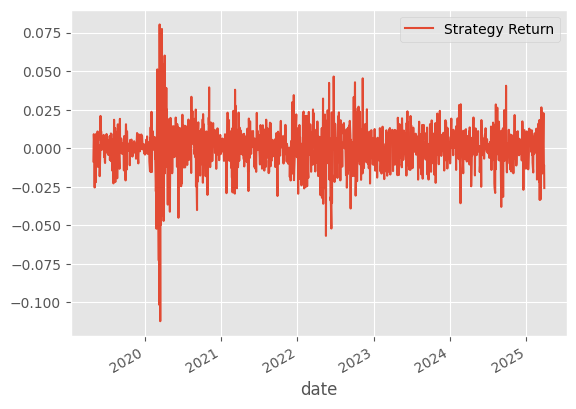

In [73]:
portfolio_df.plot()

8. Visualize Portfolio returns and compare to SP500 returns.

In [75]:
returns_dataframe.head()

Ticker,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,ADP,ADSK,ALGN,AMAT,AMD,AMGN,AMT,AMZN,AVGO,AXP,AZO,BA,BAC,BDX,BIIB,BKNG,BLK,BMY,BRK-B,BSX,C,CAT,CCL,CHTR,CI,CMCSA,CMG,COP,COST,CRM,CRWD,CSCO,CSX,CVS,CVX,DAL,DASH,DD,DE,DG,DHR,DIS,EA,EBAY,EL,ELV,EOG,EXPE,F,FCX,FDX,FI,FIS,GE,GILD,GM,GOOG,GOOGL,GS,HAL,HD,HON,HUM,IBM,INTC,INTU,ISRG,JNJ,JPM,KO,LIN,LLY,LMT,LOW,LRCX,LULU,LUV,MA,MAR,MCD,MDLZ,MDT,META,MGM,MMM,MO,MPC,MRK,MRNA,MS,MSFT,MU,NCLH,NEE,NEM,NFLX,NKE,NOC,NOW,NVDA,NXPI,ORCL,ORLY,OXY,PANW,PARA,PEP,PFE,PG,PLTR,PM,PYPL,QCOM,RCL,REGN,RTX,SBUX,SCHW,SHW,SLB,SPGI,STZ,T,TGT,TJX,TMO,TMUS,TSLA,TXN,UAL,UBER,ULTA,UNH,UNP,UPS,USB,V,VLO,VRTX,VZ,WBA,WDAY,WDC,WFC,WMT,WYNN,XOM
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-01,0.022970,0.055598,NaN,0.011800,0.004750,0.011129,0.017139,0.006079,0.009171,0.005946,0.024658,0.022718,-0.030256,-0.009283,0.010247,0.004176,-0.001723,0.012159,-0.012125,0.001002,0.007904,0.003685,0.000638,-0.006792,0.010685,0.007098,0.026118,-0.000293,0.000415,0.016514,0.029456,-0.004375,0.021120,0.006311,0.003201,-0.003099,0.017370,NaN,0.012119,0.007716,-0.026556,-0.002000,0.009909,NaN,-0.002851,0.000296,0.000104,0.005666,-0.002695,0.015559,-0.001321,-0.021570,-0.001951,-0.005175,-0.014346,0.001778,-0.017242,-0.010328,0.010808,0.048203,-0.001422,0.004558,-0.008748,0.019449,0.021532,-0.006990,-0.010434,-0.000920,-0.001176,0.003427,0.000276,0.032590,0.013171,0.015242,-0.003802,0.000000,-0.014452,0.005101,-0.024980,-0.039351,0.006409,0.028394,-0.001003,0.002080,0.011046,0.006709,-0.024179,-0.012995,0.010922,0.010756,-0.000637,0.003236,-0.001427,-0.027199,-0.015234,NaN,0.003674,0.015702,0.017463,0.007267,-0.004219,-0.001783,0.002685,-0.004249,-0.047112,-0.004343,0.009911,-0.008713,0.006112,0.010450,-0.008841,0.008328,0.008299,-0.018094,-0.033610,-0.005267,NaN,-0.009804,0.002677,-0.003732,0.012583,-0.008134,-0.009954,0.009680,-0.001258,0.016616,-0.002336,0.007554,-0.014909,-0.004905,-0.021300,-0.015200,0.001757,-0.018009,0.020276,0.019236,0.012360,NaN,-0.001156,0.001902,-0.006758,-0.009294,0.005338,0.004953,-0.001894,-0.004450,-0.010798,-0.015622,0.006229,0.012612,0.011482,-0.011941,0.029946,-0.010343
2018-05-02,0.043228,-0.016795,NaN,-0.016629,-0.007997,-0.013388,-0.006322,0.027071,-0.014268,-0.007468,-0.007492,-0.014480,0.000886,0.010089,-0.007982,-0.007144,-0.009683,-0.003137,-0.016368,-0.012431,-0.015176,-0.001749,-0.013661,-0.006158,-0.022844,-0.009268,-0.007149,-0.003817,-0.003885,-0.019849,-0.016674,0.007513,-0.023991,-0.011307,-0.003965,-0.013058,-0.002358,NaN,-0.021875,-0.007884,-0.030762,0.005033,-0.007231,NaN,0.006796,-0.004591,-0.001451,-0.013270,-0.004407,-0.007455,-0.017332,-0.088989,-0.027331,-0.007771,0.008161,-0.004451,0.010645,-0.016733,-0.036973,-0.011809,0.009210,-0.081514,-0.006059,-0.012543,-0.014225,-0.011132,0.003807,0.006909,-0.010644,-0.025805,-0.017742,-0.019311,-0.007021,0.003257,-0.020120,-0.007938,-0.012523,-0.013529,-0.003040,-0.008988,0.011982,-0.004580,0.000401,-0.013885,0.030433,-0.025318,-0.017031,-0.028618,-0.013546,0.012631,-0.005749,-0.002670,-0.006086,0.039537,-0.011797,NaN,-0.002125,-0.015809,-0.019422,-0.034568,0.001408,-0.000765,0.000191,0.002346,-0.000195,0.000484,-0.003661,-0.012288,-0.009621,0.002856,0.003260,0.013152,-0.012576,-0.019353,-0.014511,-0.014276,NaN,-0

Downloading SPY ETF Data

This code downloads historical price data for the SPY ETF (S&P 500 Index ETF) using the yfinance library and displays information about the resulting DataFrame.

This code retrieves SPY ETF data to use as a benchmark for comparing the performance of the previously implemented trading strategy. SPY is commonly used as a benchmark because:

1. **Market Representation**: It tracks the S&P 500 index, representing the broad U.S. stock market
2. **Liquidity**: It's one of the most liquid ETFs in the world
3. **Low Costs**: It has minimal tracking error and low expense ratio
4. **Tradability**: It's an actual tradable instrument, not just an index

In [76]:
spy = yf.download(tickers='SPY',
                  start='2019-05-01',
                  end=dt.date.today(), auto_adjust=False)

#spy.index.name = 'Date'
#spy.columns = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

print(spy.columns)
print(spy.index)

spy.head()

[*********************100%***********************]  1 of 1 completed

MultiIndex([('Adj Close', 'SPY'),
            (    'Close', 'SPY'),
            (     'High', 'SPY'),
            (      'Low', 'SPY'),
            (     'Open', 'SPY'),
            (   'Volume', 'SPY')],
           names=['Price', 'Ticker'])
DatetimeIndex(['2019-05-01', '2019-05-02', '2019-05-03', '2019-05-06',
               '2019-05-07', '2019-05-08', '2019-05-09', '2019-05-10',
               '2019-05-13', '2019-05-14',
               ...
               '2025-03-24', '2025-03-25', '2025-03-26', '2025-03-27',
               '2025-03-28', '2025-03-31', '2025-04-01', '2025-04-02',
               '2025-04-03', '2025-04-04'],
              dtype='datetime64[ns]', name='Date', length=1492, freq=None)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2019-05-01,265.886078,291.809998,294.950012,291.799988,294.720001,71671900
2019-05-02,265.312134,291.179993,292.700012,289.519989,291.679993,65030200
2019-05-03,267.908936,294.029999,294.339996,291.299988,292.820007,56543700
2019-05-06,266.806305,292.820007,293.309998,288.899994,289.250000,107198100
2019-05-07,262.350739,287.929993,290.809998,285.809998,290.149994,144729900


Calculating SPY Returns

This code processes the SPY ETF data to calculate daily log returns and prepare it for comparison with the previously implemented trading strategy.

This code prepares SPY return data for benchmark comparison by:

1. **Calculating Returns**: Converting price data to log returns, which are:
   - Additive over time (unlike percentage returns)
   - More normally distributed (helpful for statistical analysis)
   - Symmetric for gains and losses

2. **Cleaning the Data**: Removing NaN values and simplifying the column structure

3. **Labeling Appropriately**: Renaming to 'SPY Buy&Hold' to clearly indicate this represents a passive investment strategy

In [77]:
print(spy[['Adj Close']])
print("++++")


spy_ret = np.log(spy[['Adj Close']]).diff().dropna().rename({'Adj Close':'SPY Buy&Hold'}, axis=1)

spy_ret.columns = spy_ret.columns.droplevel('Ticker')

print(spy_ret)

Price        Adj Close
Ticker             SPY
Date                  
2019-05-01  265.886078
2019-05-02  265.312134
2019-05-03  267.908936
2019-05-06  266.806305
2019-05-07  262.350739
...                ...
2025-03-31  559.390015
2025-04-01  560.969971
2025-04-02  564.520020
2025-04-03  536.700012
2025-04-04  505.279999

[1492 rows x 1 columns]
++++
Price       SPY Buy&Hold
Date                    
2019-05-02     -0.002161
2019-05-03      0.009740
2019-05-06     -0.004124
2019-05-07     -0.016841
2019-05-08     -0.001390
...                  ...
2025-03-31      0.006690
2025-04-01      0.002820
2025-04-02      0.006308
2025-04-03     -0.050537
2025-04-04     -0.060327

[1491 rows x 1 columns]


Merging Strategy and Benchmark Returns

This code merges the previously calculated portfolio strategy returns with the SPY benchmark returns to create a combined DataFrame for performance comparison.

In [78]:
portfolio_df = portfolio_df.merge(spy_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df

,Strategy Return,SPY Buy&Hold
2019-05-02,-0.001362,-0.002161
2019-05-03,0.009077,0.009740
2019-05-06,-0.000077,-0.004124
2019-05-07,-0.025516,-0.016841
2019-05-08,0.000524,-0.001390
...,...,...
2025-03-24,0.022756,0.017750
2025-03-25,0.001373,0.002401
2025-03-26,-0.012687,-0.012010
2025-03-27,-0.011117,-0.002659


## Code Explanation: Visualizing Cumulative Returns

This code creates a visualization of the cumulative returns for both the trading strategy and the SPY benchmark over time.

This plot visualizes:

1. **Comparative Performance**: How the unsupervised learning trading strategy (likely based on the cluster analysis) performs compared to a simple buy-and-hold strategy of the S&P 500 ETF (SPY)

2. **Time Series Trends**: The evolution of returns over time, showing periods of outperformance and underperformance

3. **Cumulative Growth**: The total return an investor would have achieved by following each approach

4. **Risk Characteristics**: Indirectly shows volatility through the smoothness/choppiness of the lines

### Key Insights from Such a Plot:

From this type of visualization, analysts typically look for:

1. **Overall Outperformance**: Whether the strategy line ends higher than the benchmark

2. **Consistency**: Whether the strategy consistently outperforms or if outperformance is concentrated in specific periods

3. **Drawdowns**: How the strategy performs during market downturns (does it provide protection?)

4. **Correlation**: How closely the strategy tracks the benchmark (similar or different patterns)

5. **Inflection Points**: When the strategy begins to outperform or underperform the benchmark


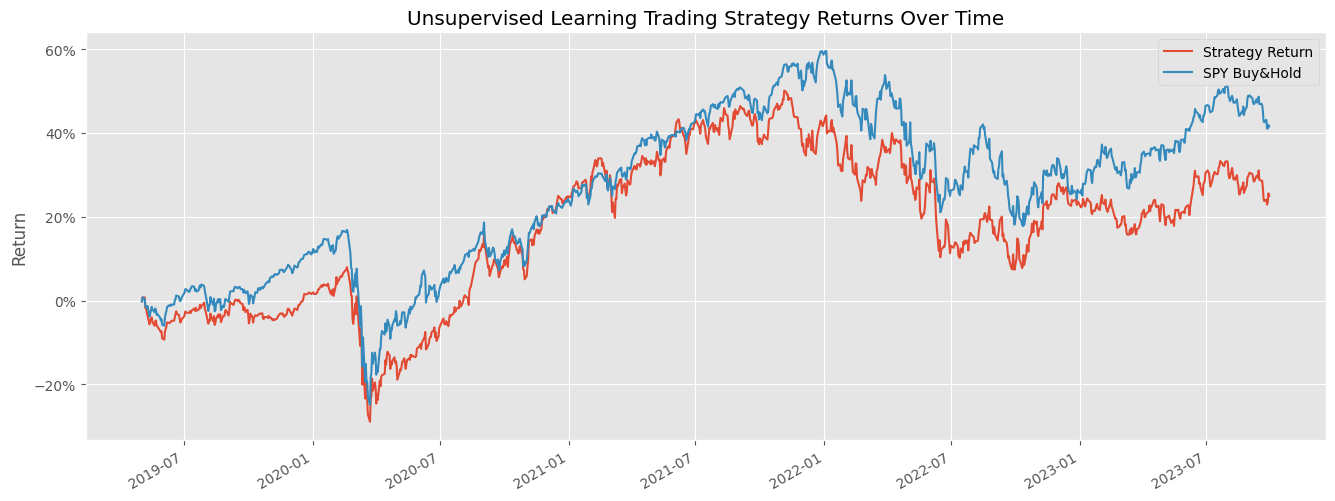

In [79]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1

portfolio_cumulative_return[:'2023-09-29'].plot(figsize=(16,6))

plt.title('Unsupervised Learning Trading Strategy Returns Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()

# [B] Building A Twitter Sentiment Investing Strategy

1. Load Twitter Sentiment Data

Load the twitter sentiment dataset, set the index, calculat engagement ratio and filter out stocks with no significant twitter activity.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import os
plt.style.use('ggplot')


sentiment_df = pd.read_csv('sentiment_data.csv')

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

sentiment_df = sentiment_df.set_index(['date', 'symbol'])

sentiment_df['engagement_ratio'] = sentiment_df['twitterComments']/sentiment_df['twitterLikes']

sentiment_df = sentiment_df[(sentiment_df['twitterLikes']>20)&(sentiment_df['twitterComments']>10)]

sentiment_df

twitterPosts  twitterComments  twitterLikes  \
date       symbol                                                
2021-11-18 AAPL           811.0           2592.0       21674.0   
           AMD            150.0            675.0        2949.0   
           AMZN           557.0           1315.0       12969.0   
           ATVI            82.0             36.0         131.0   
           BA              61.0             55.0         342.0   
...                         ...              ...           ...   
2023-01-04 T              184.0           3409.0       14271.0   
           TSLA          6767.0         540711.0     3810688.0   
           TSN             35.0            168.0         460.0   
           V              132.0           1008.0        5943.0   
           XOM            212.0            374.0        2071.0   

                   twitterImpressions  twitterSentiment  engagement_ratio  
date       symbol                                                          
2021-11-18 AAPL             7981808.0               NaN          0.119590  
           AMD              1645270.0               NaN          0.228891  
           AMZN             5590695.0               NaN          0.101396  
           ATVI             1310715.0               NaN          0.274809  
           BA                425847.0               NaN          0.160819  
...                               ...               ...               ...  
2023-01-04 T                 884935.0          0.590457          0.238876  
           TSLA            55464921.0          0.543057          0.141893  
           TSN                57207.0          0.561900          0.365217  
           V                 139835.0          0.567286          0.169611  
           XOM               483389.0          0.588914          0.180589  

[25375 rows x 6 columns]

2. Aggregate Monthly and calculate average sentiment for the month

Aggregate on a monthly level and calculate average monthly metric, for the one we choose.

In [86]:
aggragated_df = (sentiment_df.reset_index('symbol').groupby([pd.Grouper(freq='M'), 'symbol'])
                    [['engagement_ratio']].mean())

aggragated_df['rank'] = (aggragated_df.groupby(level=0)['engagement_ratio']
                         .transform(lambda x: x.rank(ascending=False)))

aggragated_df

engagement_ratio  rank
date       symbol                        
2021-11-30 AAL             0.203835  37.0
           AAPL            0.256318  23.0
           ABBV            0.244677  26.0
           ABT             0.313368  14.0
           AES             0.864613   2.0
...                             ...   ...
2023-01-31 TMO             0.333313  19.0
           TSLA            0.151992  72.0
           TSN             0.280553  30.0
           V               0.194045  60.0
           XOM             0.217904  53.0

[1109 rows x 2 columns]

3. Select Top 5 Stocks based on their cross-sectional ranking for each month

Select top 5 stocks by rank for each month and fix the date to start at beginning of next month.

In [89]:
filtered_df = aggragated_df[aggragated_df['rank']<6].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'symbol'])

filtered_df.head(20)

engagement_ratio  rank
date       symbol                        
2021-12-01 AES             0.864613   2.0
           FCX             0.626323   5.0
           MNST            0.699721   3.0
           OXY             2.147741   1.0
           SLB             0.647374   4.0
2022-01-01 D               0.801994   5.0
           FCX             0.841220   4.0
           L               6.507246   1.0
           LUV             1.303215   2.0
           MA              0.883401   3.0
2022-02-01 AMD             0.715556   4.0
           D               1.136678   1.0
           FCX             0.655237   5.0
           LUV             1.035258   2.0
           MA              0.729063   3.0
2022-03-01 FCX             1.138332   2.0
           GILD            0.530886   5.0
           LUV             1.574377   1.0
           MRO             0.581748   4.0
           OXY             1.025579   3.0

4. Extract the stocks to form portfolios with at the start of each new month

Create a dictionary containing start of month and corresponded selected stocks.

In [92]:
dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:
    
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
    
fixed_dates

{'2021-12-01': ['AES', 'FCX', 'MNST', 'OXY', 'SLB'],
 '2022-01-01': ['D', 'FCX', 'L', 'LUV', 'MA'],
 '2022-02-01': ['AMD', 'D', 'FCX', 'LUV', 'MA'],
 '2022-03-01': ['FCX', 'GILD', 'LUV', 'MRO', 'OXY'],
 '2022-04-01': ['A', 'CRM', 'PFE', 'PM', 'STZ'],
 '2022-05-01': ['AMD', 'CRM', 'CVX', 'J', 'KEY'],
 '2022-06-01': ['AMD', 'DD', 'FCX', 'KEY', 'LMT'],
 '2022-07-01': ['CB', 'CRM', 'DD', 'FCX', 'STZ'],
 '2022-08-01': ['A', 'DD', 'JPM', 'REGN', 'STZ'],
 '2022-09-01': ['ABT', 'DIS', 'L', 'META', 'MRNA'],
 '2022-10-01': ['J', 'KEY', 'L', 'META', 'MU'],
 '2022-11-01': ['A', 'DD', 'FCX', 'J', 'META'],
 '2022-12-01': ['AEP', 'AES', 'DD', 'J', 'STZ'],
 '2023-01-01': ['A', 'AES', 'DAL', 'J', 'KEY'],
 '2023-02-01': ['A', 'AES', 'BIIB', 'FCX', 'MDT']}

5. Download fresh stock prices for only selected/shortlisted stocks

In [94]:
stocks_list = sentiment_df.index.get_level_values('symbol').unique().tolist()

prices_df = yf.download(tickers=stocks_list, auto_adjust=False,
                        start='2017-01-01',
                        end='2025-03-01')

#print(prices_df.head())
prices_df[['Adj Close']]

[**********************86%****************       ]  73 of 85 completed404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/ATVI?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=ATVI&crumb=d0vmG8obJ8S
[*********************100%***********************]  85 of 85 completed

2 Failed downloads:
['MRO']: YFTzMissingError('possibly delisted; no timezone found')
['ATVI']: AttributeError("'NoneType' object has no attribute 'update'")


Price        Adj Close                                                 \
Ticker               A        AAL         AAP        AAPL        ABBV   
Date                                                                    
2017-01-03   43.651134  44.741226  153.079987   26.862429   43.851753   
2017-01-04   44.223888  45.127766  154.336121   26.832363   44.470078   
2017-01-05   43.698082  44.345028  154.228455   26.968811   44.807358   
2017-01-06   45.059544  44.654263  152.209503   27.269466   44.821407   
2017-01-09   45.200371  45.494968  152.119797   27.519245   45.116512   
...                ...        ...         ...         ...         ...   
2025-02-24  134.993210  15.310000   42.810001  247.100006  204.080002   
2025-02-25  133.895523  15.130000   45.880001  247.039993  204.139999   
2025-02-26  134.184921  15.180000   37.700001  240.360001  203.009995   
2025-02-27  126.810593  14.530000   36.959999  237.300003  205.020004   
2025-02-28  127.648804  14.350000   36.900002  241.839996  209.029999   

Price                                                                 \
Ticker             ABT         AEP        AES        ALB         AMD   
Date                                                                   
2017-01-03   33.611679   46.813828   8.724218  79.166145   11.430000   
2017-01-04   33.878517   46.880951   8.649400  81.548775   11.430000   
2017-01-05   34.171169   47.134567   8.537165  81.270050   11.240000   
2017-01-06   35.100754   47.097275   8.843934  81.647690   11.320000   
2017-01-09   35.066326   46.478153   8.626948  81.350990   11.490000   
...                ...         ...        ...        ...         ...   
2025-02-24  134.949997  106.290001  10.720000  80.576729  108.110001   
2025-02-25  135.820007  107.639999  10.860000  77.981323  103.959999   
2025-02-26  135.960007  106.889999  10.920000  77.096306  104.739998   
2025-02-27  135.869995  105.160004  10.380000  78.528252   99.510002   
2025-02-28  138.009995  106.050003  11.590000  76.599098   99.860001   

Price                                                                       \
Ticker            AMZN ATVI        AVGO          BA        BIIB        BKR   
Date                                                                         
2017-01-03   37.683498  NaN   13.924572  145.533691  291.709991  36.176277   
2017-01-04   37.859001  NaN   13.825413  147.063461  294.049988  36.020519   
2017-01-05   39.022499  NaN   13.607573  147.146927  293.570007  35.797993   
2017-01-06   39.799500  NaN   13.787934  147.508469  295.000000  35.581051   
2017-01-09   39.846001  NaN   13.817608  146.785339  299.019989  35.180504   
...                ...  ...         ...         ...         ...        ...   
2025-02-24  212.710007  NaN  207.302704  179.910004  141.270004  44.619999   
2025-02-25  212.800003  NaN  201.928970  178.270004  143.460007  44.040001   
2025-02-26  214.350006  NaN  212.297592  173.039993  140.490005  43.509998   
2025-02-27  208.740005  NaN  197.203278  173.830002  139.880005  43.580002   
2025-02-28  212.279999  NaN  198.828354  174.630005  140.500000  44.590000   

Price                                                               \
Ticker            BMY          C          CB        CCL        CMG   
Date                                                                 
2017-01-03  44.688675  46.622730  112.873138  46.789993   7.495400   
2017-01-04  44.749210  47.253704  112.710327  47.400215   7.637200   
2017-01-05  45.498306  46.430363  111.947624  48.198891   7.837800   
2017-01-06  45.362106  46.591949  112.547516  48.145050   7.968800   
2017-01-09  45.195652  46.338024  111.844772  48.180946   7.901200   
...               ...        ...         ...        ...        ...   
2025-02-24  57.259357  78.540001  272.577667  23.629999  51.209999   
2025-02-25  57.585815  78.139999  276.575012  23.740000  52.470001   
2025-02-26  56.764721  79.070000  272.796967  24.120001  53.419998   
2025-02-27  58.169491  78.870003  2

6. Calculate Portfolio Returns with monthly rebalancing

Equal-Weighted Portfolio Returns Calculation

This code calculates the returns of an equal-weighted portfolio using the stocks selected from the cluster analysis for each trading period.

### Step-by-Step Explanation:

1. **Calculate Log Returns**:
   - `np.log(prices_df['Adj Close']).diff()` - Computes daily log returns from adjusted close prices
   - `.iloc[1:]` - Removes the first row which contains NaN values (since there's no previous price for the first day)

2. **Initialize Results DataFrame**:
   - `portfolio_df = pd.DataFrame()` - Creates an empty DataFrame to store portfolio returns

3. **Print Trading Dates**:
   - `print(fixed_dates.keys())` - Displays all the dates in the trading calendar

4. **Loop Through Trading Dates**:
   - `for start_date in fixed_dates.keys():` - Processes each date in the trading calendar

5. **Define Time Periods**:
   - `end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd()).strftime('%Y-%m-%d')`
   - Sets the end of the holding period to the end of the month
   - This creates a holding period from the start date to the end of that month

6. **Get Selected Stocks**:
   - `cols = fixed_dates[start_date]` - Retrieves the list of tickers to include in the portfolio for this period

7. **Calculate Equal-Weighted Portfolio Returns**:
   - `returns_df[start_date:end_date][cols]` - Selects returns for the chosen stocks during the holding period
   - `.mean(axis=1)` - Calculates the simple average (equal-weighted) return across all stocks for each day
   - `.to_frame('portfolio_return')` - Converts the result to a DataFrame with column name 'portfolio_return'

8. **Print Period Results**:
   - `print(temp_df)` - Displays the portfolio returns for the current period

9. **Append to Results**:
   - `portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)` - Adds this period's returns to the overall results

10. **Print Cumulative Results**:
    - `print(portfolio_df)` - Displays the accumulated portfolio returns after each period

11. **Return Final Results**:
    - `portfolio_df` - Returns the complete DataFrame of portfolio returns
   
This code implements a simpler version of the portfolio backtesting framework compared to the previous optimization-based approach:

1. **Equal-Weighted Allocation**: Instead of optimizing weights, it simply allocates equally across all selected stocks
   - This is equivalent to 1/N allocation, where N is the number of stocks in the portfolio

2. **Monthly Rebalancing**: The portfolio is rebalanced at the start of each period based on the new cluster selections

3. **Performance Tracking**: The daily returns of the equal-weighted portfolio are calculated and stored


In [96]:
returns_df = np.log(prices_df['Adj Close']).diff().iloc[1:] # dropping first row NA via .iloc[1:]

#print("returns_df>>>" , returns_df)

portfolio_df = pd.DataFrame()

print(fixed_dates.keys())

for start_date in fixed_dates.keys():
    
    end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd()).strftime('%Y-%m-%d')
    
    cols = fixed_dates[start_date]
    
    temp_df = returns_df[start_date:end_date][cols].mean(axis=1).to_frame('portfolio_return')

    print(temp_df)
    
    portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

    print(portfolio_df)
    
portfolio_df

dict_keys(['2021-12-01', '2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01', '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01'])
            portfolio_return
Date                        
2021-12-01         -0.016417
2021-12-02          0.024872
2021-12-03         -0.007711
2021-12-06          0.023926
2021-12-07          0.030547
2021-12-08          0.001167
2021-12-09         -0.011651
2021-12-10          0.007106
2021-12-13         -0.025418
2021-12-14         -0.004009
2021-12-15         -0.001547
2021-12-16          0.007431
2021-12-17         -0.008607
2021-12-20         -0.021578
2021-12-21          0.034294
2021-12-22          0.007703
2021-12-23          0.005461
2021-12-27          0.014412
2021-12-28          0.001098
2021-12-29         -0.001999
2021-12-30         -0.000155
2021-12-31          0.003967
            portfolio_return
Date                        
2021-12-01         -0.01

,portfolio_return
Date,
2021-12-01,-0.016417
2021-12-02,0.024872
2021-12-03,-0.007711
2021-12-06,0.023926
2021-12-07,0.030547
...,...
2023-02-22,-0.007870
2023-02-23,-0.007323
2023-02-24,-0.009463


7. Download NASDAQ/QQQ prices and calculate returns to compare to our strategy

Adding NASDAQ ETF (QQQ) as Additional Benchmark

This code downloads QQQ ETF data (tracking the NASDAQ-100 index), calculates its returns, and adds them to the portfolio returns DataFrame for additional benchmark comparison.

This code adds the NASDAQ-100 ETF (QQQ) as an additional benchmark for comparison with the trading strategy. This is valuable because:

1. **Multiple Benchmarks**: Comparing against both S&P 500 (SPY) and NASDAQ-100 (QQQ) provides a more comprehensive performance evaluation

2. **Different Market Segments**: 
   - SPY represents the broad market (500 largest US companies)
   - QQQ represents large-cap growth and technology stocks (100 largest non-financial NASDAQ companies)

3. **Style Analysis**: Helps determine if the strategy's performance is more aligned with the broader market or with tech/growth stocks

4. **Attribution Analysis**: Enables analysis of whether outperformance comes from stock selection or from sector/style tilts

In [98]:
qqq_df = yf.download(tickers='QQQ', auto_adjust=False,
                     start='2021-01-01',
                     end='2025-03-01')


# Calculate QQQ Log Returns
# Computes daily log returns from adjusted close prices
# This creates a Series of QQQ returns
qqq_ret = np.log(qqq_df['Adj Close']).diff()
print(qqq_ret)

#qqq_ret = np.log(qqq_df['Adj Close']).diff().to_frame('nasdaq_return')

# Merge with Portfolio Returns, Combines the portfolio returns with QQQ returns
portfolio_df = portfolio_df.merge(qqq_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df

[*********************100%***********************]  1 of 1 completed

Ticker           QQQ
Date                
2021-01-04       NaN
2021-01-05  0.008211
2021-01-06 -0.013949
2021-01-07  0.023904
2021-01-08  0.012776
...              ...
2025-02-24 -0.011874
2025-02-25 -0.012679
2025-02-26  0.002413
2025-02-27 -0.028164
2025-02-28  0.015668

[1044 rows x 1 columns]


,portfolio_return,QQQ
Date,,
2021-12-01,-0.016417,-0.017159
2021-12-02,0.024872,0.007181
2021-12-03,-0.007711,-0.017542
2021-12-06,0.023926,0.007981
2021-12-07,0.030547,0.029669
...,...,...
2023-02-22,-0.007870,0.000748
2023-02-23,-0.007323,0.008696
2023-02-24,-0.009463,-0.016886


## portfolio_return	nasdaq_return

Visualizing Cumulative Returns with Multiple Benchmarks

This code creates a visualization comparing the cumulative returns of the portfolio strategy against benchmark indices over time.

This plot visualizes:

1. **Comparative Performance**: How the portfolio strategy performs compared to both the S&P 500 (SPY) and NASDAQ-100 (QQQ) indices

2. **Time Series Trends**: The evolution of returns over time, showing periods of outperformance and underperformance

3. **Cumulative Growth**: The total return an investor would have achieved by following each approach

4. **Relative Strength**: Whether the strategy performs more like the broad market (SPY) or tech-heavy index (QQQ)

### Key Insights from Such a Plot:

From this type of visualization, analysts typically look for:

1. **Overall Performance Ranking**: Which line ends highest (best overall performance)

2. **Correlation Patterns**: Whether the strategy tracks more closely with SPY or QQQ

3. **Market Regime Performance**: How the strategy performs in different market environments:
   - Bull markets (rising indices)
   - Bear markets (falling indices)
   - High volatility periods
   - Sector rotations

4. **Alpha Generation**: Whether the strategy line consistently stays above both benchmark lines, indicating added value

5. **Risk Characteristics**: The relative smoothness/choppiness of the strategy line compared to benchmarks

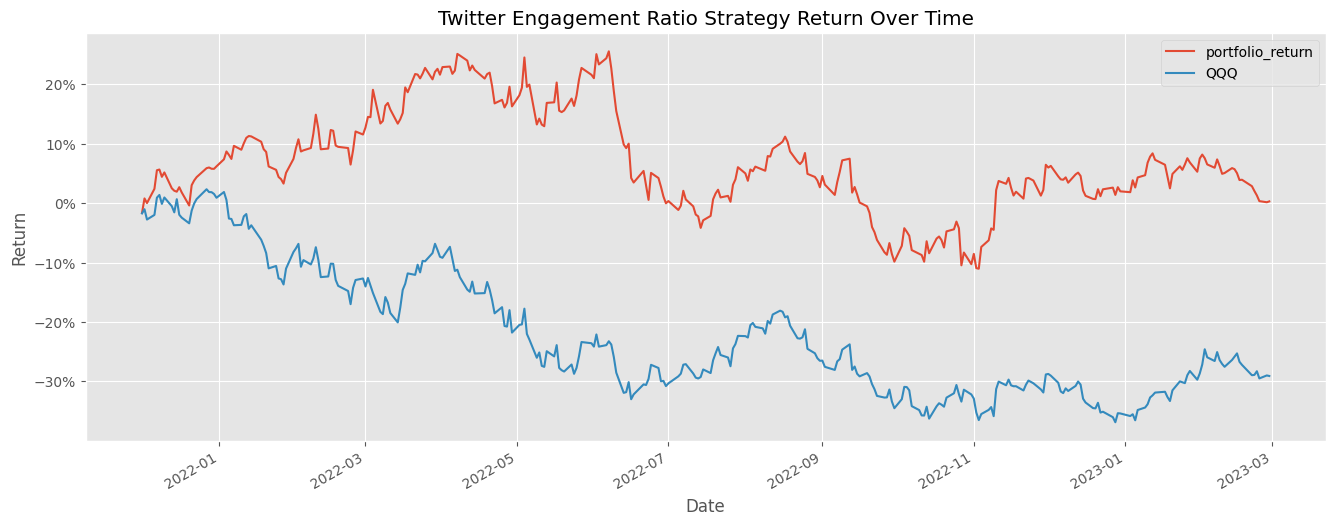

In [100]:
portfolios_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum()).sub(1)

portfolios_cumulative_return.plot(figsize=(16,6))

plt.title('Twitter Engagement Ratio Strategy Return Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()

# [C] Building An Intraday Strategy Using GARCH Model

An intraday trading strategy using a GARCH model involves forecasting and managing volatility within the trading day. GARCH models, which stand for Generalized Auto-Regressive Conditional Heteroskedasticity, are used to predict the volatility of asset returns. This can be helpful in creating strategies that adjust to changing market conditions during the day. 

Using simulated daily data and intraday 5-min data.
Load Daily and 5-minute data.
Define function to fit GARCH model on the daily data and predict 1-day ahead volatility in a rolling window.
Calculate prediction premium and form a daily signal from it.
Merge with intraday data and calculate intraday indicators to form the intraday signal.
Generate the position entry and hold until the end of the day.
Calculate final strategy returns.

(mymasterenv) PS C:\ANACONDA3\envs>conda activate mymasterenv
(mymasterenv) PS C:\ANACONDA3\envs>pip install arch

In [104]:
!pip install arch


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Load Simulated Daily and Simulated 5-minute data.

We are loading both datasets, set the indexes and calculate daily log returns.

The `arch` package (Autoregressive Conditional Heteroskedasticity) is a specialized Python library designed for financial econometrics, particularly for modeling time-varying volatility in financial time series.

The `arch_model` function specifically allows you to:

1. Create various ARCH-type models including GARCH, EGARCH, and GJR-GARCH
2. Specify model parameters like lag orders (p,q)
3. Fit these models to financial return data
4. Generate volatility forecasts

This import is essential for any analysis involving conditional heteroskedasticity modeling in financial time series.

In [107]:
from arch import arch_model

In [108]:
import matplotlib.pyplot as plt
from arch import arch_model
import pandas_ta
import pandas as pd
import numpy as np
import os

daily_df = pd.read_csv('simulated_daily_data.csv')

daily_df = daily_df.drop('Unnamed: 7', axis=1)

daily_df['Date'] = pd.to_datetime(daily_df['Date'])

daily_df = daily_df.set_index('Date')

daily_df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,116.466003,117.043503,113.105499,114.333504,114.333504,21056800.0
2014-09-18,114.214996,114.214996,103.276001,106.110001,106.110001,34483200.0
2014-09-19,106.025749,106.958748,96.133003,98.698998,98.698998,37919700.0
2014-09-20,98.668251,105.823998,97.470749,102.225998,102.225998,36863600.0
2014-09-21,102.021248,103.106499,98.295250,99.705254,99.705254,26580100.0


This preprocessing prepares the intraday data for further analysis by ensuring proper datetime formatting and creating a date-only column that can be useful for grouping or filtering by day.
This code is processing a 5-minute intraday financial dataset.

In [109]:
intraday_5min_df = pd.read_csv('simulated_5min_data.csv')

# Removes an unnecessary column named 'Unnamed: 6' from the DataFrame. This is likely an empty or artifact column created during the CSV export
intraday_5min_df = intraday_5min_df.drop('Unnamed: 6', axis=1)
# Converts the 'datetime' column from string format to pandas datetime objects, enabling proper time-based operations.
intraday_5min_df['datetime'] = pd.to_datetime(intraday_5min_df['datetime'])
# Creates a new 'date' column that contains just the date part (without time) from the datetime index, converted to pandas datetime objects.
intraday_5min_df = intraday_5min_df.set_index('datetime')

intraday_5min_df['date'] = pd.to_datetime(intraday_5min_df.index.date)

intraday_5min_df.head()

,open,low,high,close,volume,date
datetime,,,,,,
2021-09-29 20:00:00,10379.7775,10364.5950,10398.7025,10370.9575,46,2021-09-29
2021-09-29 20:05:00,10370.9425,10352.4175,10380.2500,10371.1450,53,2021-09-29
2021-09-29 20:10:00,10372.8150,10357.8250,10388.7500,10384.3125,116,2021-09-29
2021-09-29 20:15:00,10385.8275,10384.0825,10457.2000,10442.5175,266,2021-09-29
2021-09-29 20:20:00,10442.5225,10426.2375,10448.0000,10440.9950,65,2021-09-29


2. Define function to fit GARCH model and predict 1-day ahead volatility in a rolling window.

This approach allows for dynamic volatility forecasting that adapts to changing market conditions, potentially capturing volatility clustering (periods of high volatility tend to be followed by high volatility, and vice versa) better than simple historical variance calculations.

In [111]:
# calculates log returns of the adjusted closing prices, Log returns are commonly used in financial analysis as they're approximately equal to percentage changes for small moves.
daily_df['log_ret'] = np.log(daily_df['Adj Close']).diff()
# It computes a 180-day rolling variance of these log returns as a baseline measure of volatility
daily_df['variance'] = daily_df['log_ret'].rolling(180).var()
# The data is filtered to include only entries from 2020 onwards.
daily_df = daily_df['2020':]

# The `predict_volatility` function:
# Takes a window of log returns
# Scales the returns by multiplying by 100 (to avoid numerical issues in the optimization)
# Fits a GARCH(1,3) model to the data (p=1 for ARCH terms, q=3 for GARCH terms)
# Forecasts the variance one day ahead
# Returns this forecasted variance
def predict_volatility(x):

    # DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer.
    # This happens because the returns you're passing to the arch_model are very small (e.g., like 0.0008), which is typical for log returns, but it makes optimization harder
    # Solution: Rescale the data -> You can simply multiply your returns by 100 before passing them to the arch_model, here y=100*x
    best_model = arch_model(y=100*x,
                            p=1,
                            q=3).fit(update_freq=5,
                                     disp='off')
    
    variance_forecast = best_model.forecast(horizon=1).variance.iloc[-1,0]

    print(x.index[-1])
    
    return variance_forecast

#The function is applied to a 180-day rolling window of log returns, creating predictions for each day based on the previous 180 days of data.
daily_df['predictions'] = daily_df['log_ret'].rolling(180).apply(lambda x: predict_volatility(x))
#rows with NaN values are removed
daily_df = daily_df.dropna()

daily_df

2020-06-28 00:00:00
2020-06-29 00:00:00
2020-06-30 00:00:00
2020-07-01 00:00:00
2020-07-02 00:00:00
2020-07-03 00:00:00
2020-07-04 00:00:00
2020-07-05 00:00:00
2020-07-06 00:00:00
2020-07-07 00:00:00
2020-07-08 00:00:00
2020-07-09 00:00:00
2020-07-10 00:00:00
2020-07-11 00:00:00
2020-07-12 00:00:00
2020-07-13 00:00:00
2020-07-14 00:00:00
2020-07-15 00:00:00
2020-07-16 00:00:00
2020-07-17 00:00:00
2020-07-18 00:00:00
2020-07-19 00:00:00
2020-07-20 00:00:00
2020-07-21 00:00:00
2020-07-22 00:00:00
2020-07-23 00:00:00
2020-07-24 00:00:00
2020-07-25 00:00:00
2020-07-26 00:00:00
2020-07-27 00:00:00
2020-07-28 00:00:00
2020-07-29 00:00:00
2020-07-30 00:00:00
2020-07-31 00:00:00
2020-08-01 00:00:00
2020-08-02 00:00:00
2020-08-03 00:00:00
2020-08-04 00:00:00
2020-08-05 00:00:00
2020-08-06 00:00:00
2020-08-07 00:00:00
2020-08-08 00:00:00
2020-08-09 00:00:00
2020-08-10 00:00:00
2020-08-11 00:00:00
2020-08-12 00:00:00
2020-08-13 00:00:00
2020-08-14 00:00:00
2020-08-15 00:00:00
2020-08-16 00:00:00


C:\ANACONDA3\envs\mymasterenv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


2021-03-11 00:00:00
2021-03-12 00:00:00
2021-03-13 00:00:00
2021-03-14 00:00:00
2021-03-15 00:00:00
2021-03-16 00:00:00
2021-03-17 00:00:00
2021-03-18 00:00:00
2021-03-19 00:00:00
2021-03-20 00:00:00
2021-03-21 00:00:00
2021-03-22 00:00:00
2021-03-23 00:00:00
2021-03-24 00:00:00
2021-03-25 00:00:00
2021-03-26 00:00:00
2021-03-27 00:00:00
2021-03-28 00:00:00
2021-03-29 00:00:00
2021-03-30 00:00:00
2021-03-31 00:00:00
2021-04-01 00:00:00
2021-04-02 00:00:00
2021-04-03 00:00:00
2021-04-04 00:00:00
2021-04-05 00:00:00
2021-04-06 00:00:00
2021-04-07 00:00:00
2021-04-08 00:00:00
2021-04-09 00:00:00
2021-04-10 00:00:00
2021-04-11 00:00:00
2021-04-12 00:00:00
2021-04-13 00:00:00
2021-04-14 00:00:00
2021-04-15 00:00:00
2021-04-16 00:00:00
2021-04-17 00:00:00
2021-04-18 00:00:00
2021-04-19 00:00:00
2021-04-20 00:00:00
2021-04-21 00:00:00
2021-04-22 00:00:00
2021-04-23 00:00:00
2021-04-24 00:00:00
2021-04-25 00:00:00
2021-04-26 00:00:00
2021-04-27 00:00:00
2021-04-28 00:00:00
2021-04-29 00:00:00


,Open,High,Low,Close,Adj Close,Volume,log_ret,variance,predictions
Date,,,,,,,,,
2020-06-28,2262.115234,2299.386719,2243.881348,2285.895508,2285.895508,1.456087e+10,0.010797,0.002473,7.282031
2020-06-29,2285.007324,2309.393311,2260.468994,2297.713623,2297.713623,1.646055e+10,0.005157,0.002473,6.512710
2020-06-30,2296.395264,2304.458984,2271.209473,2284.498291,2284.498291,1.573580e+10,-0.005768,0.002468,8.769092
2020-07-01,2286.496338,2327.438721,2276.183838,2307.081299,2307.081299,1.597155e+10,0.009837,0.002455,6.177787
2020-07-02,2307.784912,2318.740723,2259.155762,2280.852539,2280.852539,1.633892e+10,-0.011434,0.002456,7.027252
...,...,...,...,...,...,...,...,...,...
2023-09-14,6557.069336,6693.655762,6542.862793,6634.918457,6634.918457,1.381136e+10,0.011801,0.000393,3.337612
2023-09-15,6633.454590,6710.124512,6560.175293,6652.173340,6652.173340,1.147974e+10,0.002597,0.000385,2.922781
2023-09-16,6651.549805,6688.692383,6618.472656,6642.070313,6642.070313,7.402031e+09,-0.001520,0.000384,2.857576


3. Calculate prediction premium and form a daily signal from it.

In [113]:
daily_df['prediction_premium'] = (daily_df['predictions']-daily_df['variance'])/daily_df['variance']

daily_df['premium_std'] = daily_df['prediction_premium'].rolling(180).std()

# The 'signal_daily' column contains only three possible values:
# 1: When the premium exceeds the positive standard deviation threshold
# -1: When the premium falls below the negative standard deviation threshold
# NaN: When the premium is between these thresholds
# The distribution pattern would reveal whether your strategy generates more buy signals, more sell signals, or if they're roughly balanced.
daily_df['signal_daily'] = daily_df.apply(lambda x: 1 if (x['prediction_premium']>x['premium_std'])
                                         else (-1 if (x['prediction_premium']<x['premium_std']*-1) else np.nan),
                                         axis=1)

daily_df['signal_daily'] = daily_df['signal_daily'].shift()

daily_df

,Open,High,Low,Close,Adj Close,Volume,log_ret,variance,predictions,prediction_premium,premium_std,signal_daily
Date,,,,,,,,,,,,
2020-06-28,2262.115234,2299.386719,2243.881348,2285.895508,2285.895508,1.456087e+10,0.010797,0.002473,7.282031,2943.503266,NaN,NaN
2020-06-29,2285.007324,2309.393311,2260.468994,2297.713623,2297.713623,1.646055e+10,0.005157,0.002473,6.512710,2632.341380,NaN,NaN
2020-06-30,2296.395264,2304.458984,2271.209473,2284.498291,2284.498291,1.573580e+10,-0.005768,0.002468,8.769092,3552.333294,NaN,NaN
2020-07-01,2286.496338,2327.438721,2276.183838,2307.081299,2307.081299,1.597155e+10,0.009837,0.002455,6.177787,2515.461852,NaN,NaN
2020-07-02,2307.784912,2318.740723,2259.155762,2280.852539,2280.852539,1.633892e+10,-0.011434,0.002456,7.027252,2860.828416,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-14,6557.069336,6693.655762,6542.862793,6634.918457,6634.918457,1.381136e+10,0.011801,0.000393,3.337612,8480.910296,6348.102894,1.0
2023-09-15,6633.454590,6710.124512,6560.175293,6652.173340,6652.173340,1.147974e+10,0.002597,0.000385,2.922781,7591.516854,6284.346160,1.0
2023-09-16,6651.549805,6688.692383,6618.472656,6642.070313,6642.070313,7.402031e+09,-0.001520,0.000384,2.857576,7431.618630,6284.309380,1.0


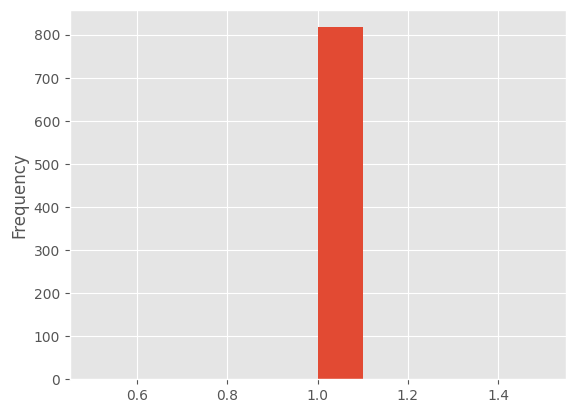

In [114]:
# The 'ggplot' style gives the histogram a distinctive gray background with white grid lines for better readability.
plt.style.use('ggplot')
# This creates a histogram of the 'signal_daily' column from the DataFrame called 'daily_df'. A histogram shows the distribution of values by grouping them into bins and displaying the frequency of values in each bin.
daily_df['signal_daily'].plot(kind='hist')
#This displays the plot.
plt.show()

4. Merge with intraday data and calculate intraday indicators to form the intraday signal.

This code implements step 4 of merging intraday data with daily data and calculating intraday indicators to form an intraday signal. Here's a step-by-step explanation:
1. The code merges a 5-minute intraday dataframe with a daily dataframe:
   - Resets the index of the intraday dataframe
   - Merges it with the daily dataframe (keeping only the 'signal_daily' column)
   - Joins on 'date' from intraday data and 'Date' from daily data
   - Drops the redundant date columns
   - Sets 'datetime' as the index
2. Calculates technical indicators using the pandas_ta library:
   - RSI (Relative Strength Index) with a 20-period lookback
   - Bollinger Bands with a 20-period lookback, extracting lower and upper bands
3. Creates an 'signal_intraday' column based on the indicators:
   - Sets 1 (bullish) when RSI > 70 and price > upper Bollinger Band
   - Sets -1 (bearish) when RSI < 30 and price < lower Bollinger Band
   - Sets NaN for all other conditions
4. Calculates log returns of the close prices
5. Returns the final dataframe with all the new columns
This code effectively combines daily signals with intraday technical indicators to create a comprehensive trading signal framework.

In [116]:
final_df = intraday_5min_df.reset_index()\
                            .merge(daily_df[['signal_daily']].reset_index(),
                                   left_on='date',
                                   right_on='Date')\
                            .drop(['date','Date'], axis=1)\
                            .set_index('datetime')

# Calculates technical indicators using the pandas_ta library
# RSI (Relative Strength Index) with a 20-period lookback
final_df['rsi'] = pandas_ta.rsi(close=final_df['close'],
                                length=20)

# Bollinger Bands with a 20-period lookback, extracting lower and upper bands
final_df['lband'] = pandas_ta.bbands(close=final_df['close'],
                                     length=20).iloc[:,0]
final_df['uband'] = pandas_ta.bbands(close=final_df['close'],
                                     length=20).iloc[:,2]

# Creates an 'signal_intraday' column based on the indicators:
# Sets 1 (bullish) when RSI > 70 and price > upper Bollinger Band
# Sets -1 (bearish) when RSI < 30 and price < lower Bollinger Band
# Sets NaN for all other conditions
final_df['signal_intraday'] = final_df.apply(lambda x: 1 if (x['rsi']>70)&
                                                            (x['close']>x['uband'])
                                             else (-1 if (x['rsi']<30)&
                                                         (x['close']<x['lband']) else np.nan),
                                             axis=1)

# Calculates log returns of the close prices
final_df['return'] = np.log(final_df['close']).diff()

final_df

,open,low,high,close,volume,signal_daily,rsi,lband,uband,signal_intraday,return
datetime,,,,,,,,,,,
2021-09-29 20:00:00,10379.7775,10364.5950,10398.7025,10370.9575,46,1.0,NaN,NaN,NaN,NaN,NaN
2021-09-29 20:05:00,10370.9425,10352.4175,10380.2500,10371.1450,53,1.0,NaN,NaN,NaN,NaN,0.000018
2021-09-29 20:10:00,10372.8150,10357.8250,10388.7500,10384.3125,116,1.0,NaN,NaN,NaN,NaN,0.001269
2021-09-29 20:15:00,10385.8275,10384.0825,10457.2000,10442.5175,266,1.0,NaN,NaN,NaN,NaN,0.005589
2021-09-29 20:20:00,10442.5225,10426.2375,10448.0000,10440.9950,65,1.0,NaN,NaN,NaN,NaN,-0.000146
...,...,...,...,...,...,...,...,...,...,...,...
2023-09-18 23:35:00,6708.0025,6705.5175,6712.0000,6708.8675,11,1.0,62.861699,6677.365065,6715.855435,NaN,0.000128
2023-09-18 23:40:00,6708.8650,6707.1800,6714.2500,6709.3350,22,1.0,63.165869,6679.544207,6716.559793,NaN,0.000070
2023-09-18 23:45:00,6709.9250,6704.3600,6713.5000,6708.2750,25,1.0,61.954798,6682.379916,6716.534084,NaN,-0.000158


5. Generate the position entry and hold until the end of the day.

This code is creating and calculating a trading strategy's returns based on daily and intraday signals. Here's a step-by-step explanation:
1. The first line creates a new column 'return_sign' in final_df that:
   - Sets -1 when both daily and intraday signals are 1
   - Sets 1 when both daily and intraday signals are -1
   - Sets NaN for all other combinations
2. The second part uses groupby with Grouper(freq='D') to group data by day, then applies forward fill (ffill) to propagate the return_sign values within each day, filling any NaN values with the last valid value.
3. The code then creates a 'forward_return' column by shifting the 'return' column one period back (to get the next period's return).
4. It calculates 'strategy_return' by multiplying the forward return by the return sign, effectively determining if the strategy is long (1) or short (-1) the market.
5. Finally, it aggregates the strategy returns by day using groupby and sum, then displays the first few rows of the resulting daily returns.

In [118]:
final_df['return_sign'] = final_df.apply(lambda x: -1 if (x['signal_daily']==1)&(x['signal_intraday']==1)
                                        else (1 if (x['signal_daily']==-1)&(x['signal_intraday']==-1) else np.nan),
                                        axis=1)

final_df['return_sign'] = final_df.groupby(pd.Grouper(freq='D'))['return_sign']\
                                  .transform(lambda x: x.ffill())

final_df['forward_return'] = final_df['return'].shift(-1)

final_df['strategy_return'] = final_df['forward_return']*final_df['return_sign']

daily_return_df = final_df.groupby(pd.Grouper(freq='D'))['strategy_return'].sum()

daily_return_df.head()

datetime
2021-09-29   -0.007912
2021-09-30    0.003285
2021-10-01   -0.066914
2021-10-02    0.000000
2021-10-03    0.000000
Freq: D, Name: strategy_return, dtype: float64

6. Calculate final strategy returns.

This code creates a visualization of cumulative investment returns over time. Specifically:
1. It calculates the cumulative returns from daily return data using a financial mathematics approach (log returns)
2. It plots these cumulative returns as a line chart, showing how the investment strategy performed over time
3. It formats the y-axis as percentages (e.g., 0.05 displays as 5%) to make the returns more readable
4. It adds appropriate labels and title to make the chart informative

The end result is a time series chart showing the total percentage return of an investment strategy from the beginning of the period to each point in time, allowing you to visualize the performance trajectory of the strategy.

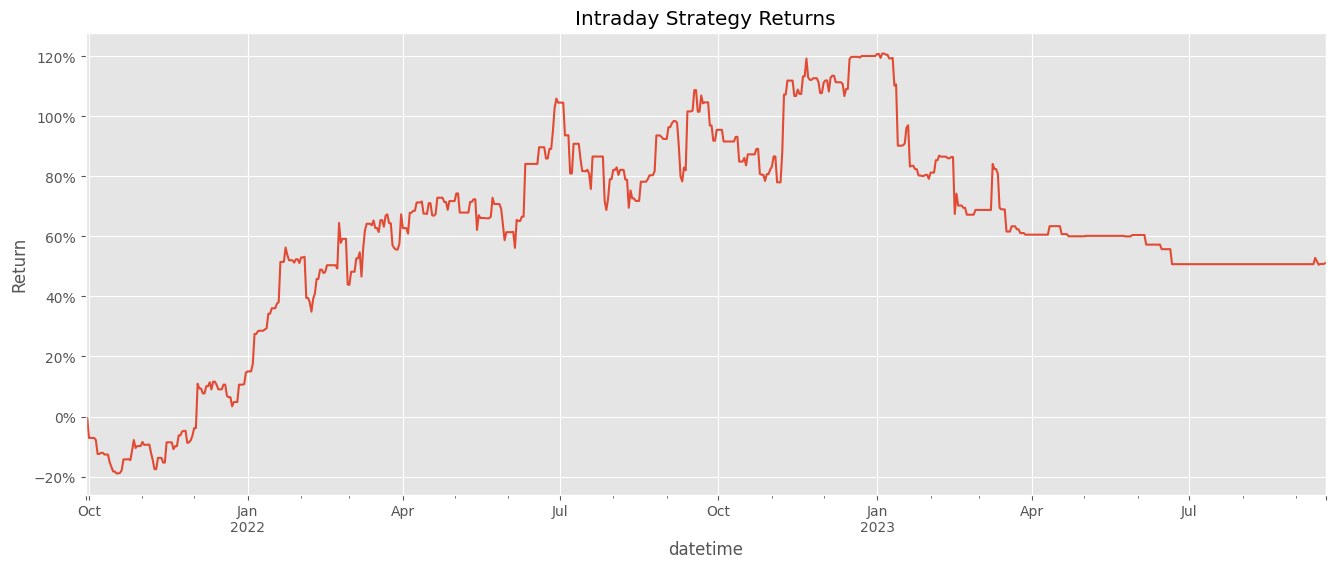

In [120]:
import matplotlib.ticker as mtick

strategy_cumulative_return = np.exp(np.log1p(daily_return_df).cumsum()).sub(1)

strategy_cumulative_return.plot(figsize=(16,6))

plt.title('Intraday Strategy Returns')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()
             